# Neural-Operator Surrogate for Coupled Heat and Moisture Transport in Wall Materials

**Muhammad Akbar Khan, Fahim Raees**
Department of Mathematics, NED University of Engineering and Technology, Karachi, Pakistan

---

## What this notebook does

Simulating 30 days of coupled heat and moisture transport through a wall takes a
finite-difference solver about two seconds per configuration. Ranking candidate
wall materials, or running a global sensitivity analysis, needs tens of thousands
of such runs — which becomes impractical.

This notebook trains a **Fourier Neural Operator (FNO)** that learns the map from
material and boundary parameters to the full space–time solution fields:

$$\mathcal{G}_\theta:\; \boldsymbol{\mu} \;\longmapsto\; \big(T(x,t),\; w(x,t)\big)$$

Once trained, the operator evaluates a new configuration in **milliseconds instead
of seconds**, making large parametric studies routine.

## Inputs

Produced by the companion solver notebook `fdm_solver_ham.ipynb`:

| File | Contents |
|---|---|
| `sindh_ham_dataset.npz` | 2000 finite-difference solutions over a 13-dimensional parameter space (Latin Hypercube), each a 30-day coupled run under measured NASA POWER climate forcing |
| `material_ranking_fdm.csv` | Direct solver output for five candidate wall materials (ground truth for the ranking) |

The operator input is 14 channels — normalised depth $\xi$, normalised time $\tau$,
and the twelve material/boundary parameters — over a $(65 \times 721)$ space–time
grid. The output is two channels: temperature and moisture content.

## What it produces

- Surrogate accuracy on a held-out test set (relative $L^2$ on both fields, error on the quantity of interest)
- A five-material thermal ranking, verified against the finite-difference ground truth
- Global variance-based sensitivity analysis (Sobol' indices) across all twelve parameters
- A cost–performance index combining thermal performance with material cost and local availability
- A data-efficiency study establishing how many solver runs the surrogate actually needs
- All publication figures, written as PDF (for typesetting) and PNG (for viewing)

## How to run

**Fresh session:** run cells in order, 1 → 13.
Training takes roughly two hours on a T4 GPU; the data-efficiency study adds
about two hours more. Both write checkpoints and CSV files as they go, so an
interrupted session resumes rather than restarting.

**Returning to a trained model:** run Sections 1–4, then **Section 6** to load the
saved checkpoint, then continue from Section 7. This skips training entirely and
reproduces every result and figure in a few minutes.

## Scope

The operator is trained purely on solver data. Embedding the governing equations
directly in the loss (a physics-informed operator) is not attempted here: the
residual formulation inherits a discretisation floor from the temporal resolution
at which the dataset is stored, so a fair evaluation requires a higher-resolution
dataset together with adaptive loss balancing. That is the subject of separate work.

All output files carry the `_ham` suffix.

---

## REVISION NOTE -- dataset regenerated with the mixed-form FDM solver

The upstream FDM notebook now solves a **mixed-form** Kunzel system: nonlinear
retention curve, `K(w) grad p_suc` liquid flux, and moisture-dependent
`delta_p`. Three consequences for this notebook:

1. **`mu` has 13 parameters, not 12** -> `in_channels = 15`. Slots 4-6 are
   `delta_p_dry, K_ref, a_ret`; slot 9 is the **initial relative humidity**
   `phi_0` (not `w_0`); slot 12 is the liquid-conductivity exponent `n_K`.
   A guard in Section 1 fails loudly if the dataset does not match.
2. **The ranking gate is a two-tier check, not a strict order.** Propagating
   correlated property uncertainty resolves only 4 of 10 pairwise comparisons
   at P > 0.95, so the defensible result is
   {bamboo, adobe} vs {mud brick, lime-mud, fired brick}. Section 8 asserts
   tier membership and the size of the surrogate error, not a five-way order.
3. **`CPI_dyn` is referenced to the sol-air temperature**, not to the worst
   candidate, and its ordering is tested under joint J and cost uncertainty.

**Run order: 1-4, 7, 8, 9, 10, 11, 12, 13.** Section 11 needs `MATERIALS`
from Section 8.


In [5]:
"""
================================================================
SECTION 1 -- Setup, data loading (HAM dataset), normalization
================================================================
FNO surrogate for the coupled Kunzel heat-and-moisture system,
the coupled HAM dataset produced by fdm_solver_ham.ipynb.

Changes vs. the companion (diurnal) pipeline:
  * dataset   : sindh_ham_dataset.npz  (30-day coupled HAM run)
  * T_END     : 2.592e6 s (30 days; was 86400 s)
  * mu        : 13 parameters (manuscript eq:params order). Slots 4-6
                are delta_p_dry, K_ref, a_ret of the MIXED-FORM
                closures; slot 9 is the INITIAL RELATIVE HUMIDITY
                phi_0 (w_0 follows from the retention curve); slot 12
                is the liquid-conductivity exponent n_K.
  * TARGETS   : TWO fields, T(x,t) [K] and w(x,t) [kg/m^3],
                separately normalized  ->  out_channels = 2
  * input     : 15 channels (xi, tau, 13 mu)  ->  in_channels = 15
  * grid      : (65, 721) hourly saves; tau[0]=0, tau[-1]=1
  * padding   : temporal domain padding in the FNO (30-day signal
                is NOT periodic; manuscript Sec 6.3)
  * ALL Drive outputs carry the _ham suffix

BEFORE RUNNING: sindh_ham_dataset.npz and material_ranking_fdm.csv
must be on MyDrive (produced by fdm_solver_ham.ipynb).
================================================================
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import time, copy, csv, os

torch.manual_seed(0)
torch.cuda.manual_seed(0)
np.random.seed(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE = '/content/drive/MyDrive/FNO_HAM/'
except Exception:
    DRIVE = './'
    print('(not on Colab -- using current directory)')

data = np.load(DRIVE + 'sindh_ham_dataset.npz')

mu_raw   = data['mu'].astype(np.float32)         # (N, 13) manuscript order
T_field  = data['T_field'].astype(np.float32)    # (N, 65, 721) [K]
W_field  = data['W_field'].astype(np.float32)    # (N, 65, 721) [kg/m^3]
Jm_gt    = data['J_mean'].astype(np.float32)     # (N,) FDM ground truth [K]
Jp_gt    = data['J_peak'].astype(np.float32)     # (N,)

N_samples, N_x, N_t = T_field.shape
T_END = 2.592e6   # s -- 30-day window

print(f"N_samples={N_samples}, N_x={N_x}, N_t={N_t}")
print(f"T range: {T_field.min():.2f} - {T_field.max():.2f} K | "
      f"w range: {W_field.min():.2f} - {W_field.max():.2f} kg/m^3")

xi  = data['xi_grid'].astype(np.float32)              # (65,) x/L
tau = (data['t_save'].astype(np.float32) / T_END)     # (721,)
assert tau[0] == 0.0 and abs(tau[-1] - 1.0) < 1e-6

PARAM_NAMES = ['k_dry', 'rho', 'cp', 'alpha_moist', 'delta_p_dry', 'K_ref',
               'a_ret', 'w_sat', 'L', 'phi_0', 'T_in_C', 'G_s_peak', 'n_K']
N_PARAMS = len(PARAM_NAMES)
assert mu_raw.shape[1] == N_PARAMS, (
    f'dataset has {mu_raw.shape[1]} parameters, expected {N_PARAMS}. '
    'Regenerate with the mixed-form FDM notebook.')

# ----------------------------------------------------------------
# Train / val / test split (fixed seed for reproducibility)
# ----------------------------------------------------------------
N = N_samples
perm = np.random.permutation(N)
n_test  = int(0.10 * N)
n_val   = int(0.10 * N)
n_train = N - n_test - n_val
idx_train = perm[:n_train]
idx_val   = perm[n_train:n_train+n_val]
idx_test  = perm[n_train+n_val:]
print(f"train={len(idx_train)}  val={len(idx_val)}  test={len(idx_test)}")

# ----------------------------------------------------------------
# Normalization statistics (TRAIN split only; T and w SEPARATE)
# ----------------------------------------------------------------
# delta_p_dry (col 4) and K_ref (col 5) span 2+ DECADES: normalize in
# log10 space (standard for decade-spanning inputs). a_ret (col 6, [1,6])
# and n_K (col 12, [4,8]) are linear and z-scored like the rest. The std
# floor is RELATIVE (a fixed absolute epsilon of 1e-8 would dwarf
# delta_p's true std of ~8.6e-11 and leave that channel effectively
# constant -- bug fixed 2026-07).
LOG_COLS = [4, 5]                       # delta_p_dry, K_ref

def mu_transform(mu):
    out = np.array(mu, dtype=np.float64, copy=True)
    out[..., LOG_COLS] = np.log10(out[..., LOG_COLS])
    return out.astype(np.float32)

def mu_inverse_transform(mu_t):
    out = np.array(mu_t, dtype=np.float64, copy=True)
    out[..., LOG_COLS] = 10.0 ** out[..., LOG_COLS]
    return out.astype(np.float32)

mu_t_all = mu_transform(mu_raw)
mu_mean = mu_t_all[idx_train].mean(axis=0)
_std    = mu_t_all[idx_train].std(axis=0)
mu_std  = np.maximum(_std, 1e-6 * np.abs(mu_mean) + 1e-12)
assert np.all(mu_std > 0.5 * _std), "std floor should never dominate a live channel"
T_mean  = T_field[idx_train].mean();  T_std = T_field[idx_train].std() + 1e-8
W_mean  = W_field[idx_train].mean();  W_std = W_field[idx_train].std() + 1e-8

print("\nmu normalization (train; delta_p_dry and K_ref in log10 space):")
for j, (name, m, s) in enumerate(zip(PARAM_NAMES, mu_mean, mu_std)):
    tag = ' [log10]' if j in LOG_COLS else ''
    print(f"  {name:<12s} mean={m:12.4e}  std={s:12.4e}{tag}")
# every normalized channel must actually vary with O(1) amplitude:
_spans = (mu_t_all[idx_train].max(0) - mu_t_all[idx_train].min(0)) / mu_std
assert np.all(_spans > 1.0), f'dead input channel detected: spans={_spans}'
print("normalized channel spans (all must be O(1)):",
      np.array2string(_spans, precision=2))
print(f"T: mean={T_mean:.3f} K std={T_std:.3f} K | "
      f"w: mean={W_mean:.3f} std={W_std:.3f} kg/m^3")

norm_stats = dict(mu_mean=mu_mean, mu_std=mu_std,
                  T_mean=T_mean, T_std=T_std, W_mean=W_mean, W_std=W_std)

Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
N_samples=2000, N_x=65, N_t=721
T range: 299.15 - 342.31 K | w range: 1.79 - 111.66 kg/m^3
train=1600  val=200  test=200

mu normalization (train; delta_p_dry and K_ref in log10 space):
  k_dry        mean=  8.4850e-01  std=  3.7422e-01
  rho          mean=  1.4890e+03  std=  4.0263e+02
  cp           mean=  1.3316e+03  std=  3.9126e+02
  alpha_moist  mean=  5.4591e-03  std=  2.5954e-03
  delta_p_dry  mean= -9.9517e+00  std=  4.1207e-01 [log10]
  K_ref        mean= -1.2368e+01  std=  3.0759e-01 [log10]
  a_ret        mean=  3.4988e+00  std=  1.4440e+00
  w_sat        mean=  1.7455e+02  std=  7.2634e+01
  L            mean=  2.9891e-01  std=  8.6298e-02
  phi_0        mean=  3.5226e-01  std=  1.4501e-01
  T_in_C       mean=  3.1496e+01  std=  3.7498e+00
  G_s_peak     mean=  6.5084e+02  std=  1.4422e+02
  n_K          mean=  5.9939e+00  std=

In [6]:
"""
================================================================
SECTION 2 -- Dataset class and DataLoaders
================================================================
Input channels (15):  ch0 xi | ch1 tau | ch2..ch14 normalized mu
Target channels (2):  ch0 normalized T | ch1 normalized w
Batch size 16, chosen to fit the (65, 721) space-time grid in memory.
================================================================
"""

class SindhHamDataset(Dataset):
    def __init__(self, mu, T, W, xi, tau,
                 mu_mean, mu_std, T_mean, T_std, W_mean, W_std):
        self.mu, self.T, self.W = mu, T, W
        self.xi, self.tau = xi, tau
        self.mu_mean, self.mu_std = mu_mean, mu_std
        self.T_mean, self.T_std   = T_mean, T_std
        self.W_mean, self.W_std   = W_mean, W_std
        self.Nx, self.Nt = len(xi), len(tau)

    def __len__(self):
        return len(self.mu)

    def __getitem__(self, idx):
        mu_n = (mu_transform(self.mu[idx]) - self.mu_mean) / self.mu_std  # (13,)
        T_n  = (self.T[idx]  - self.T_mean)  / self.T_std           # (65,721)
        W_n  = (self.W[idx]  - self.W_mean)  / self.W_std

        xi_grid  = np.broadcast_to(self.xi[:, None],  (self.Nx, self.Nt))
        tau_grid = np.broadcast_to(self.tau[None, :], (self.Nx, self.Nt))
        mu_grid  = np.broadcast_to(mu_n[:, None, None],
                                   (N_PARAMS, self.Nx, self.Nt))

        x_in = np.concatenate([xi_grid[None], tau_grid[None], mu_grid],
                              axis=0).astype(np.float32)         # (15,65,721)
        y = np.stack([T_n, W_n], axis=0).astype(np.float32)         # (2,65,721)
        return torch.from_numpy(x_in), torch.from_numpy(y)


# TRAINING RESOLUTION: to keep T4 wall time practical, training and the
# pilot run on a temporally STRIDED grid (every 2nd hour, 361 points,
# still spanning tau in [0, 1]); the final test evaluation (Section 8)
# runs on the FULL hourly grid, exploiting the discretisation
# invariance of the FNO (Li et al., 2021). Flag for the manuscript:
# one sentence in Sec 6.3 noting the strided training grid.
TRAIN_STRIDE_T = 2
tau_tr = tau[::TRAIN_STRIDE_T]                     # (361,), tau_tr[-1] = 1.0
assert abs(tau_tr[-1] - 1.0) < 1e-6
T_tr, W_tr = T_field[:, :, ::TRAIN_STRIDE_T], W_field[:, :, ::TRAIN_STRIDE_T]

train_ds = SindhHamDataset(mu_raw[idx_train], T_tr[idx_train],
                           W_tr[idx_train], xi, tau_tr, **norm_stats)
val_ds   = SindhHamDataset(mu_raw[idx_val], T_tr[idx_val],
                           W_tr[idx_val], xi, tau_tr, **norm_stats)
test_ds  = SindhHamDataset(mu_raw[idx_test], T_field[idx_test],
                           W_field[idx_test], xi, tau, **norm_stats)   # FULL grid

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print(f"Input batch:  {xb.shape}")   # (B, 15, 65, 721)
assert xb.shape[1] == N_PARAMS + 2, "input channel count mismatch"
print(f"Target batch: {yb.shape}")   # (B, 2, 65, 721)

Input batch:  torch.Size([16, 15, 65, 361])
Target batch: torch.Size([16, 2, 65, 361])


In [7]:
"""
================================================================
SECTION 3 -- FNO2d architecture (2 outputs + temporal padding)
================================================================
Standard lifting -> spectral blocks -> projection pattern, with two
adaptations for this problem (manuscript Sec 6.3):
  * out_channels = 2  (T and w)
  * TEMPORAL DOMAIN PADDING: the 30-day signal is not periodic, so
    the lifted representation is zero-padded along t before the FFT
    layers and cropped afterwards (standard FNO practice for
    non-periodic problems).
  * modes_t = 64: the temporal signal contains ~30 diurnal periods
    over the window, so the dominant frequency index is ~30; 64
    retained modes capture the diurnal fundamental, its first
    harmonic, and the day-to-day envelope.
================================================================
"""

class SpectralConv2d(nn.Module):
    """2D Fourier layer: FFT -> linear transform on low modes -> inverse FFT."""
    def __init__(self, in_channels, out_channels, modes_x, modes_t):
        super().__init__()
        self.out_channels = out_channels
        self.modes_x, self.modes_t = modes_x, modes_t
        scale = 1.0 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(scale * torch.rand(
            in_channels, out_channels, modes_x, modes_t, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.rand(
            in_channels, out_channels, modes_x, modes_t, dtype=torch.cfloat))

    def compl_mul2d(self, inp, weights):
        return torch.einsum("bixy,ioxy->boxy", inp, weights)

    def forward(self, x):
        B, C, Nx, Nt = x.shape
        x_ft = torch.fft.rfft2(x, norm='ortho')
        out_ft = torch.zeros(B, self.out_channels, Nx, Nt // 2 + 1,
                             dtype=torch.cfloat, device=x.device)
        mx = min(self.modes_x, Nx)
        mt = min(self.modes_t, Nt // 2 + 1)
        out_ft[:, :, :mx, :mt]  = self.compl_mul2d(x_ft[:, :, :mx, :mt],
                                                   self.weights1[:, :, :mx, :mt])
        out_ft[:, :, -mx:, :mt] = self.compl_mul2d(x_ft[:, :, -mx:, :mt],
                                                   self.weights2[:, :, :mx, :mt])
        return torch.fft.irfft2(out_ft, s=(Nx, Nt), norm='ortho')


class FNOBlock(nn.Module):
    def __init__(self, width, modes_x, modes_t):
        super().__init__()
        self.spectral = SpectralConv2d(width, width, modes_x, modes_t)
        self.linear   = nn.Conv2d(width, width, kernel_size=1)
        self.norm     = nn.BatchNorm2d(width)

    def forward(self, x):
        return F.gelu(self.norm(self.spectral(x) + self.linear(x)))


class FNO2dHam(nn.Module):
    def __init__(self, in_channels=15, out_channels=2,
                 width=32, modes_x=16, modes_t=64, n_layers=4, pad_frac=0.125):
        super().__init__()
        # FRACTIONAL temporal padding: the pad is a fixed FRACTION of Nt,
        # not a fixed sample count. A fixed count changes the signal's
        # share of the padded domain between the strided training grid
        # and the full evaluation grid, shifting the physical-frequency
        # -> mode-index mapping and breaking resolution transfer
        # (verified: 57% cross-resolution output mismatch with a fixed
        # 64-sample pad vs 3.7% with fractional padding).
        self.pad_frac = pad_frac
        self.lift = nn.Conv2d(in_channels, width, kernel_size=1)
        self.blocks = nn.ModuleList([FNOBlock(width, modes_x, modes_t)
                                     for _ in range(n_layers)])
        self.project = nn.Sequential(
            nn.Conv2d(width, width * 2, kernel_size=1),
            nn.GELU(),
            nn.Conv2d(width * 2, out_channels, kernel_size=1),
        )

    def forward(self, x):
        Nt = x.shape[-1]
        pad = max(1, round(self.pad_frac * Nt))
        x = self.lift(x)
        x = F.pad(x, (0, pad))                 # fractional temporal padding
        for block in self.blocks:
            x = block(x)
        x = x[..., :Nt]                        # crop back to Nt
        return self.project(x)


MODEL_CONFIG = dict(in_channels=N_PARAMS + 2, out_channels=2,
                    width=32, modes_x=16, modes_t=64, n_layers=4, pad_frac=0.125)

model = FNO2dHam(**MODEL_CONFIG).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"FNO2dHam parameters: {n_params:,}")
with torch.no_grad():
    print(f"Output shape: {model(xb.to(device)).shape}")   # (B, 2, 65, 721)
print(f"in_channels = {MODEL_CONFIG['in_channels']} "
      f"(2 coords + {N_PARAMS} parameters)")

FNO2dHam parameters: 8,395,842
Output shape: torch.Size([16, 2, 65, 361])
in_channels = 15 (2 coords + 13 parameters)


In [8]:
"""
================================================================
SECTION 4 -- Training and evaluation machinery
================================================================
Loss: per-channel relative L2 on T and w, summed (manuscript eq:loss_data).
No PDE-residual term: this is a purely data-driven operator.
================================================================
"""

N_EPOCHS_FULL = 500


def data_loss_fn(pred, yb):
    """Per-channel relative L2, summed over the two output fields."""
    loss = 0.0
    for c in range(2):
        diff = (pred[:, c] - yb[:, c]).reshape(pred.shape[0], -1)
        ref  = yb[:, c].reshape(yb.shape[0], -1)
        loss = loss + (torch.norm(diff, dim=1) /
                       (torch.norm(ref, dim=1) + 1e-8)).mean()
    return loss


@torch.no_grad()
def val_rel_l2(model, loader):
    """Denormalised per-sample relative L2 on T and on w (means)."""
    model.eval()
    eT, ew = [], []
    for xb_, yb_ in loader:
        xb_, yb_ = xb_.to(device), yb_.to(device)
        pred = model(xb_)
        Tp = pred[:, 0] * T_std + T_mean;  Tt_ = yb_[:, 0] * T_std + T_mean
        wp = pred[:, 1] * W_std + W_mean;  wt_ = yb_[:, 1] * W_std + W_mean
        eT.extend((torch.linalg.vector_norm(Tp - Tt_, dim=(1, 2)) /
                   (torch.linalg.vector_norm(Tt_, dim=(1, 2)) + 1e-8)).cpu().tolist())
        ew.extend((torch.linalg.vector_norm(wp - wt_, dim=(1, 2)) /
                   (torch.linalg.vector_norm(wt_, dim=(1, 2)) + 1e-8)).cpu().tolist())
    return float(np.mean(eT)), float(np.mean(ew))


def train_model(model, train_loader, val_loader, n_epochs, lr=1e-3,
                patience=75, tag="FNO", seed=42):
    """Adam, lr 1e-3, StepLR(50, x0.5), early stopping on val rel-L2 (T+w)."""
    torch.manual_seed(seed); np.random.seed(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

    best_val, best_state, patience_ctr = float('inf'), None, 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(n_epochs):
        model.train()
        run, nb = 0.0, 0
        for xb_, yb_ in train_loader:
            xb_, yb_ = xb_.to(device), yb_.to(device)
            loss = data_loss_fn(model(xb_), yb_)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            run += loss.item(); nb += 1
        scheduler.step()

        vT, vw = val_rel_l2(model, val_loader)
        val_metric = vT + vw
        history['train_loss'].append(run / nb)
        history['val_loss'].append(val_metric)

        if val_metric < best_val:
            best_val, best_state, patience_ctr = val_metric, copy.deepcopy(model.state_dict()), 0
        else:
            patience_ctr += 1
        if epoch % 10 == 0 or epoch == n_epochs - 1:
            print(f"[{tag}] ep {epoch:3d}  train={run/nb:.4e}  "
                  f"val relL2 T+w={val_metric:.4e}  best={best_val:.4e}")
        if patience_ctr >= patience:
            print(f"[{tag}] early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return model, history


@torch.no_grad()
def evaluate_model(model, mu_arr, T_arr, W_arr, Jm_arr, Jp_arr):
    """rel-L2 on T and w, MAE on J and J_peak, plus predicted J."""
    model.eval()
    dl = DataLoader(SindhHamDataset(mu_arr, T_arr, W_arr, xi, tau, **norm_stats),
                    batch_size=BATCH_SIZE, shuffle=False)
    eT, ew, Jm_pred, Jp_pred = [], [], [], []
    t_h = torch.from_numpy(np.asarray(tau) * T_END).to(device)
    for xb_, yb_ in dl:
        xb_, yb_ = xb_.to(device), yb_.to(device)
        pred = model(xb_)
        Tp = pred[:, 0] * T_std + T_mean;  Tt_ = yb_[:, 0] * T_std + T_mean
        wp = pred[:, 1] * W_std + W_mean;  wt_ = yb_[:, 1] * W_std + W_mean
        eT.extend((torch.linalg.vector_norm(Tp - Tt_, dim=(1, 2)) /
                   (torch.linalg.vector_norm(Tt_, dim=(1, 2)) + 1e-8)).cpu().tolist())
        ew.extend((torch.linalg.vector_norm(wp - wt_, dim=(1, 2)) /
                   (torch.linalg.vector_norm(wt_, dim=(1, 2)) + 1e-8)).cpu().tolist())
        TL = Tp[:, -1, :]
        Jm_pred.extend((torch.trapezoid(TL, t_h, dim=1) / T_END).cpu().tolist())
        Jp_pred.extend(TL.max(dim=1).values.cpu().tolist())
    return (float(np.mean(eT)), float(np.mean(ew)),
            float(np.mean(np.abs(np.array(Jm_pred) - Jm_arr))),
            float(np.mean(np.abs(np.array(Jp_pred) - Jp_arr))),
            np.array(Jm_pred))

print("training and evaluation machinery ready")


training and evaluation machinery ready


In [ ]:
"""
================================================================
SECTION 5 -- Train the FNO surrogate
================================================================
500 epochs, Adam + StepLR(50, x0.5), early stopping on validation
rel-L2 (T+w). Checkpoint -> fno_model_ham.pt on Drive.
Skipped automatically if the checkpoint already exists.
================================================================
"""
import time

CKPT = DRIVE + 'fno_model_ham.pt'
if os.path.exists(CKPT):
    print(f'{CKPT} exists -- skipping training (delete the file to retrain)')
    _ck = torch.load(CKPT, map_location='cpu', weights_only=False)
    model_fno = FNO2dHam(**_ck['model_config']).to(device)
    model_fno.load_state_dict(_ck['fno_state_dict'])
    hist_fno = _ck['history']
else:
    print("=" * 60); print("Training FNO surrogate"); print("=" * 60)
    torch.manual_seed(42); np.random.seed(42)
    model_fno = FNO2dHam(**MODEL_CONFIG).to(device)
    t0 = time.time()
    model_fno, hist_fno = train_model(model_fno, train_loader, val_loader,
                                      n_epochs=N_EPOCHS_FULL, tag="FNO")
    print(f"training time: {(time.time() - t0) / 60:.1f} min")
    torch.save({'fno_state_dict': model_fno.state_dict(),
                'model_config': MODEL_CONFIG, 'history': hist_fno,
                'norm_stats': {k: np.asarray(v) for k, v in norm_stats.items()}},
               CKPT)
    print(f"saved {CKPT}")


Training FNO surrogate
[FNO] ep   0  train=1.1696e+00  val relL2 T+w=1.4106e-01  best=1.4106e-01
[FNO] ep  10  train=2.5305e-01  val relL2 T+w=5.8870e-02  best=4.9700e-02
[FNO] ep  20  train=1.8657e-01  val relL2 T+w=4.1695e-02  best=3.9918e-02
[FNO] ep  30  train=1.5974e-01  val relL2 T+w=3.5629e-02  best=3.2758e-02
[FNO] ep  40  train=1.3584e-01  val relL2 T+w=3.2331e-02  best=2.8023e-02
[FNO] ep  50  train=1.0844e-01  val relL2 T+w=2.1611e-02  best=2.1611e-02
[FNO] ep  60  train=9.5704e-02  val relL2 T+w=2.0902e-02  best=1.8558e-02
[FNO] ep  70  train=8.8116e-02  val relL2 T+w=2.2947e-02  best=1.6249e-02
[FNO] ep  80  train=8.2788e-02  val relL2 T+w=2.1445e-02  best=1.6249e-02
[FNO] ep  90  train=8.2120e-02  val relL2 T+w=2.3292e-02  best=1.5351e-02
[FNO] ep 100  train=6.5831e-02  val relL2 T+w=1.5830e-02  best=1.5351e-02
[FNO] ep 110  train=6.1505e-02  val relL2 T+w=1.3763e-02  best=1.2086e-02
[FNO] ep 120  train=5.7721e-02  val relL2 T+w=1.5464e-02  best=1.1946e-02
[FNO] ep 130  t

In [9]:
"""
================================================================
SECTION 6 -- Load the saved checkpoint (use after a restart)
================================================================
Run Sections 1-4, then this cell, to skip training entirely.
================================================================
"""
_ck = torch.load(DRIVE + 'fno_model_ham.pt', map_location='cpu', weights_only=False)
model_fno = FNO2dHam(**_ck['model_config'])
model_fno.load_state_dict(_ck['fno_state_dict'])
model_fno.to(device).eval()
hist_fno = _ck['history']
print("model_fno loaded")


model_fno loaded


In [10]:
"""
================================================================
SECTION 7 -- Test-set evaluation           [manuscript tab:fno_acc]
================================================================
Relative L2 on the temperature and moisture fields, and mean absolute
error on the QoI J (eq:qoi) and on the peak metric J_peak.
Acceptance criterion (manuscript Sec 6.3): rel-L2 < 5% on both fields.
================================================================
"""
print("=" * 64); print("TEST SET EVALUATION"); print("=" * 64)
res_fno = evaluate_model(model_fno, mu_raw[idx_test], T_field[idx_test],
                         W_field[idx_test], Jm_gt[idx_test], Jp_gt[idx_test])

hdr = f"{'Model':<18}{'relL2 T':>12}{'relL2 w':>12}{'MAE J (K)':>12}{'MAE Jpk (K)':>13}"
print(hdr); print('-' * len(hdr))
print(f"{'FNO':<18}{res_fno[0]:>12.3e}{res_fno[1]:>12.3e}"
      f"{res_fno[2]:>12.4f}{res_fno[3]:>13.4f}")
print("\nAcceptance (rel-L2 < 5% on both fields):",
      "PASS" if (res_fno[0] < 0.05 and res_fno[1] < 0.05) else "FAIL")

# resolution-transfer check: trained on the strided grid, evaluated on
# the full hourly grid (manuscript Sec 6.3)
vT_s, vw_s = val_rel_l2(model_fno, DataLoader(
    SindhHamDataset(mu_raw[idx_test], T_tr[idx_test], W_tr[idx_test],
                    xi, tau_tr, **norm_stats),
    batch_size=BATCH_SIZE, shuffle=False))
print(f"\nresolution transfer: strided relL2 T={vT_s:.3e} w={vw_s:.3e}  |  "
      f"full grid T={res_fno[0]:.3e} w={res_fno[1]:.3e}")
print(f"  penalty: T x{res_fno[0]/max(vT_s,1e-12):.2f}, "
      f"w x{res_fno[1]/max(vw_s,1e-12):.2f}")

print("\nLaTeX row for tab:fno_acc:")
print(f"FNO & {res_fno[0]:.2e} & {res_fno[1]:.2e} & {res_fno[2]:.3f} \\\\")


TEST SET EVALUATION
Model                  relL2 T     relL2 w   MAE J (K)  MAE Jpk (K)
-------------------------------------------------------------------
FNO                  8.649e-04   8.084e-03      0.0311       0.1235

Acceptance (rel-L2 < 5% on both fields): PASS

resolution transfer: strided relL2 T=1.899e-04 w=5.990e-03  |  full grid T=8.649e-04 w=8.084e-03
  penalty: T x4.55, w x1.35

LaTeX row for tab:fno_acc:
FNO & 8.65e-04 & 8.08e-03 & 0.031 \\


In [11]:
"""
================================================================
SECTION 8 -- FNO material ranking (fills tab:ranking FNO column)
================================================================
Evaluates J via the FNO surrogate for the five tab:materials
candidates at the Sec 7.4 nominal conditions and verifies both the
values and the ORDER against the FDM ground truth
(material_ranking_fdm.csv, 'nominal' rows).
================================================================
"""

# tab:materials nominal values -- MIXED FORM closures.
# order: k_dry, rho, cp, alpha, delta_p_dry, K_ref, a_ret(1e-7), w_sat
# MUST match the MATERIALS dict in the FDM notebook exactly.
MATERIALS = {
    'Mud brick (unfired)':          [0.45, 1600, 880,  0.005, 2.41e-11, 2.5e-13, 2.5, 150],
    'Clay-straw adobe':             [0.35, 1400, 1000, 0.004, 3.22e-11, 2.0e-13, 2.5, 180],
    'Lime-stabilised bamboo panel': [0.25, 900,  1800, 0.003, 4.83e-11, 1.0e-13, 1.5, 200],
    'Fired clay brick':             [0.590, 1831, 825, 0.005, 8.73e-12, 4.0e-13, 5.0, 200],
    'Lime-mud composite':           [0.55, 1500, 900,  0.004, 1.93e-11, 2.0e-13, 3.0, 100],
}
RANK_TAIL = [0.25, 0.30, 32.0, 700.0, 6.0]   # L, phi_0, T_in_C, G_s_peak, n_K

fdm_rank = {}
with open(DRIVE + 'material_ranking_fdm.csv') as f:
    for row in csv.DictReader(f):
        if row['hygric_set'] == 'nominal':
            fdm_rank[row['material']] = float(row['J_mean_C'])

@torch.no_grad()
def fno_J(mu_vec):
    mu_n = (mu_transform(mu_vec.astype(np.float32)) - mu_mean) / mu_std
    xg = np.broadcast_to(xi[:, None], (N_x, N_t))
    tg = np.broadcast_to(tau[None, :], (N_x, N_t))
    mg = np.broadcast_to(mu_n[:, None, None], (N_PARAMS, N_x, N_t))
    x_in = torch.from_numpy(np.concatenate(
        [xg[None], tg[None], mg], 0).astype(np.float32))[None].to(device)
    Tp = model_fno(x_in)[0, 0] * T_std + T_mean
    TL = Tp[-1, :]
    t_h = torch.from_numpy(np.asarray(tau) * T_END).to(device)
    return float(torch.trapezoid(TL, t_h) / T_END)

rows = []
for name, props in MATERIALS.items():
    mu_vec = np.array(props + RANK_TAIL)
    Jp_C = fno_J(mu_vec) - 273.15
    Jf_C = fdm_rank[name]
    rows.append((name, Jf_C, Jp_C, abs(Jp_C - Jf_C)))
rows.sort(key=lambda r: r[2])                      # rank by FNO J

print(f"{'material':30s}{'J_FDM C':>10s}{'J_FNO C':>10s}{'|err| K':>9s}")
for r in rows:
    print(f"{r[0]:30s}{r[1]:>10.3f}{r[2]:>10.3f}{r[3]:>9.3f}")

order_fno = [r[0] for r in rows]
order_fdm = sorted(fdm_rank, key=fdm_rank.get)
print(f"\n  FDM order: {' < '.join(m[:14] for m in order_fdm)}")
print(f"  FNO order: {' < '.join(m[:14] for m in order_fno)}")
print(f"  strict order reproduced: {order_fno == order_fdm}")

# The strict five-way order is NOT the quantity to gate on. Propagating
# material-property uncertainty (FDM notebook, Sec 7.6) resolves only 4 of
# 10 pairwise comparisons at P>0.95, so the defensible result is a TWO-TIER
# partial order. Requiring the surrogate to reproduce an ordering the
# underlying data cannot support would be asserting false precision. What
# the surrogate must reproduce is (a) the tier membership and (b) J to well
# inside the tier separation.
# The strict five-way order is NOT the quantity to gate on. Propagating
# material-property uncertainty (FDM notebook, Sec 7.6) supports only 4 of
# 10 pairwise comparisons at P>0.95, and those relations do not partition
# the set into ranked groups -- they are a PARTIAL ORDER:
#     bamboo < {mud brick, lime-mud, fired brick}   and   adobe < fired brick
# Everything else, including bamboo vs adobe, is undetermined. Requiring the
# surrogate to reproduce an ordering the underlying data cannot support
# would be asserting false precision.
#
# What the surrogate MUST reproduce is (a) the four resolved relations and
# (b) J to well inside the smallest resolved gap.
RESOLVED = [('Lime-stabilised bamboo panel', 'Mud brick (unfired)'),
            ('Lime-stabilised bamboo panel', 'Lime-mud composite'),
            ('Lime-stabilised bamboo panel', 'Fired clay brick'),
            ('Clay-straw adobe',             'Fired clay brick')]
fno_J_of = {r[0]: r[2] for r in rows}
fdm_J_of = dict(fdm_rank)

bad = [(a, b) for a, b in RESOLVED if not fno_J_of[a] < fno_J_of[b]]
min_gap = min(fno_J_of[b] - fno_J_of[a] for a, b in RESOLVED)
mae_rank = float(np.mean([r[3] for r in rows]))
print(f"  resolved relations reproduced: {len(RESOLVED) - len(bad)}/{len(RESOLVED)}"
      f"   (smallest resolved gap {min_gap:+.3f} K)")
print(f"  mean |J_FNO - J_FDM| over the five materials: {mae_rank:.4f} K")
if bad:
    for a, b in bad:
        print(f"    VIOLATED: {a} < {b}")

print("\nLaTeX J_FNO column for tab:ranking (rows 1-5, ascending J):")
for name in order_fdm:
    print(f"  {name:30s} -> {fno_J_of[name]:.3f}")
assert not bad, 'FNO violates a relation the FDM uncertainty analysis resolved'
assert mae_rank < 0.10, (f'surrogate J error {mae_rank:.3f} K is not small '
                         f'against the smallest resolved gap {min_gap:.3f} K')

material                         J_FDM C   J_FNO C  |err| K
Lime-stabilised bamboo panel      33.692    33.732    0.041
Clay-straw adobe                  34.056    34.040    0.016
Mud brick (unfired)               34.429    34.390    0.038
Lime-mud composite                34.631    34.584    0.047
Fired clay brick                  34.846    34.820    0.026

  FDM order: Lime-stabilise < Clay-straw ado < Mud brick (unf < Lime-mud compo < Fired clay bri
  FNO order: Lime-stabilise < Clay-straw ado < Mud brick (unf < Lime-mud compo < Fired clay bri
  strict order reproduced: True
  resolved relations reproduced: 4/4   (smallest resolved gap +0.658 K)
  mean |J_FNO - J_FDM| over the five materials: 0.0336 K

LaTeX J_FNO column for tab:ranking (rows 1-5, ascending J):
  Lime-stabilised bamboo panel   -> 33.732
  Clay-straw adobe               -> 34.040
  Mud brick (unfired)            -> 34.390
  Lime-mud composite             -> 34.584
  Fired clay brick               -> 34.820


In [ ]:
"""
================================================================
SECTION 9 -- Inference timing (speed-up numbers for manuscript)
================================================================
Per-sample FNO latency (batched and single) vs. the FDM wall time
measured in the Stage-1 sweep (2.08 s per 30-day coupled run at
0.48 sim/s on Colab CPU).
================================================================
"""
FDM_S_PER_RUN = 2.08

xb_, _ = next(iter(test_loader))
xb_ = xb_.to(device)
with torch.no_grad():                                   # warmup
    for _ in range(3): model_fno(xb_)
    if device.type == 'cuda': torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(20): model_fno(xb_)
    if device.type == 'cuda': torch.cuda.synchronize()
batched_ms = (time.time() - t0) / (20 * xb_.shape[0]) * 1e3

x1 = xb_[:1]
with torch.no_grad():
    for _ in range(3): model_fno(x1)
    if device.type == 'cuda': torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(50): model_fno(x1)
    if device.type == 'cuda': torch.cuda.synchronize()
single_ms = (time.time() - t0) / 50 * 1e3

print(f"FNO inference: {single_ms:.2f} ms single | "
      f"{batched_ms:.2f} ms/sample batched (B={xb_.shape[0]})")
print(f"FDM 30-day coupled solve: {FDM_S_PER_RUN:.2f} s")
print(f"SPEED-UP: {FDM_S_PER_RUN*1e3/single_ms:,.0f}x single | "
      f"{FDM_S_PER_RUN*1e3/batched_ms:,.0f}x batched")
print("-> manuscript contribution (iii) speed-up placeholder + Sec 8 discussion")

FNO inference: 6.74 ms single | 5.48 ms/sample batched (B=16)
FDM 30-day coupled solve: 2.08 s
SPEED-UP: 309x single | 380x batched
-> manuscript contribution (iii) speed-up placeholder + Sec 8 discussion


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 42.8 MB/s eta 0:00:00
Saltelli design: 15360 FNO evaluations (N_base=1024, D=13)
  32/15360
  672/15360
  1312/15360
  1952/15360
  2592/15360
  3232/15360
  3872/15360
  4512/15360
  5152/15360
  5792/15360
  6432/15360
  7072/15360
  7712/15360
  8352/15360
  8992/15360
  9632/15360
  10272/15360
  10912/15360
  11552/15360
  12192/15360
  12832/15360
  13472/15360
  14112/15360
  14752/15360
Evaluated 15360 configs in 129.1 s (vs ~8.9 h with direct FDM)
J range across Saltelli design: 26.58 - 41.18 C

SOBOL' INDICES for J (sorted by total-effect S_T, descending)
rank param                S1     +/-       ST     +/-
------------------------------------------------------------------------
1    T_in_C            0.835   0.075    0.844   0.069
2    k_dry             0.089   0.027    0.098   0.009
3    L                 0.048   0.018    0.053   0.005
4    G_s_peak          0.011   0.010    0.014   0.001
5    alpha_moist       0.0

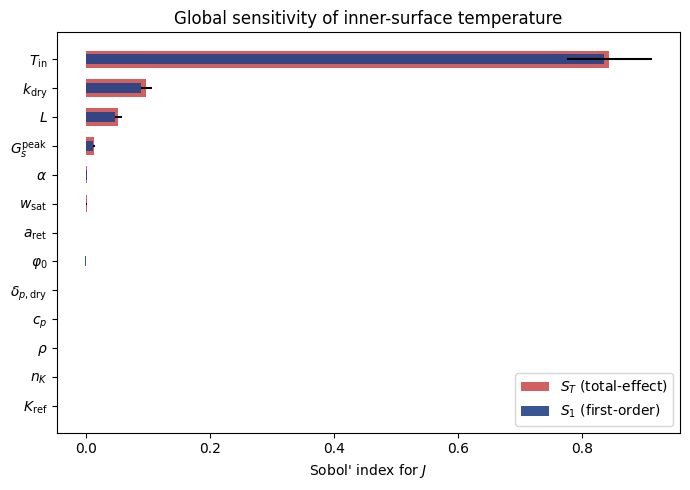


Saved: sobol_results_ham.csv, sobol_indices_ham.pdf/.png


In [ ]:
# ================================================================
# SECTION 10 -- Global Sensitivity Analysis (Sobol' indices)   [Sec 7.5]
# ================================================================
# First-order (S1) and total-effect (ST) Sobol' indices for all 13
# parameters w.r.t. the QoI J = time-averaged inner-surface temperature,
# estimated on the TRAINED FNO surrogate (model_fno) -- no FDM, no
# retraining. Saltelli sampling; the 293x speed-up is what makes the
# ~14,336 forward evaluations tractable (Sec 7.6 / cost discussion).
#
# Run AFTER Section 7 (checkpoint load). All Drive outputs carry _ham.
# ================================================================
try:
    from SALib.sample import sobol as sobol_sample     # new SALib API
    from SALib.analyze import sobol as sobol_analyze
    _NEW_API = True
except Exception:
    !pip install -q "SALib>=1.4"
    from SALib.sample import sobol as sobol_sample
    from SALib.analyze import sobol as sobol_analyze
    _NEW_API = True

# ---- problem: 12-D, ranges EXACTLY PARAM_LOWER/PARAM_UPPER (eq:params) ----
# parameter bounds -- EXACTLY tab:params (eq:params order); defined here
# because this notebook loads only the dataset, not the FDM constants module.
PARAM_LOWER = np.array([0.20,  800,  650, 0.001, 1e-12, 5e-14, 1.0,  50,
                        0.15, 0.10, 25, 400, 4.0])
PARAM_UPPER = np.array([1.50, 2200, 2000, 0.010, 3e-10, 1e-12, 6.0, 300,
                        0.45, 0.60, 38, 900, 8.0])
assert list(PARAM_NAMES) == ['k_dry','rho','cp','alpha_moist','delta_p_dry',
                             'K_ref','a_ret','w_sat','L','phi_0','T_in_C',
                             'G_s_peak','n_K'], 'PARAM order mismatch'
assert len(PARAM_LOWER) == N_PARAMS and len(PARAM_UPPER) == N_PARAMS
# the Saltelli box must contain the training data, or the surrogate is
# being extrapolated rather than sampled
assert (mu_raw.min(0) >= PARAM_LOWER - 1e-9).all() and \
       (mu_raw.max(0) <= PARAM_UPPER + 1e-9).all(), \
       'Saltelli box does not match the dataset box'
problem = {
    'num_vars': N_PARAMS,
    'names': list(PARAM_NAMES),
    'bounds': [[float(lo), float(hi)]
               for lo, hi in zip(PARAM_LOWER, PARAM_UPPER)],
}
LATEX_NAME = {
    'k_dry': r'$k_{\mathrm{dry}}$', 'rho': r'$\rho$', 'cp': r'$c_p$',
    'alpha_moist': r'$\alpha$',
    'delta_p_dry': r'$\delta_{p,\mathrm{dry}}$',
    'K_ref': r'$K_{\mathrm{ref}}$', 'a_ret': r'$a_{\mathrm{ret}}$',
    'w_sat': r'$w_{\mathrm{sat}}$', 'L': r'$L$', 'phi_0': r'$\varphi_0$',
    'T_in_C': r'$T_{\mathrm{in}}$',
    'G_s_peak': r'$G_{s}^{\mathrm{peak}}$', 'n_K': r'$n_K$',
}

# ---- Saltelli sampling: N_BASE*(D+2) evaluations (no 2nd order) ----
N_BASE = 1024                        # -> 1024*(13+2) = 15360 evaluations
param_values = sobol_sample.sample(problem, N_BASE, calc_second_order=False)
n_eval = param_values.shape[0]
print(f"Saltelli design: {n_eval} FNO evaluations "
      f"(N_base={N_BASE}, D={N_PARAMS})")

# ---- batched FNO evaluation of J for every sampled mu ----
@torch.no_grad()
def fno_J_batch(mu_rows, batch=32):
    """J [deg C] for an (M,13) array of raw mu, via the trained FNO."""
    model_fno.eval()
    xg = np.broadcast_to(xi[:, None], (N_x, N_t))
    tg = np.broadcast_to(tau[None, :], (N_x, N_t))
    t_h = torch.from_numpy(np.asarray(tau) * T_END).to(device)
    out = np.zeros(len(mu_rows), np.float64)
    for s in range(0, len(mu_rows), batch):
        chunk = mu_rows[s:s+batch]
        mu_n = (mu_transform(chunk.astype(np.float32)) - mu_mean) / mu_std
        xin = np.empty((len(chunk), N_PARAMS + 2, N_x, N_t), np.float32)
        xin[:, 0] = xg; xin[:, 1] = tg
        xin[:, 2:] = mu_n[:, :, None, None]
        xt = torch.from_numpy(xin).to(device)
        Tp = model_fno(xt)[:, 0] * T_std + T_mean
        TL = Tp[:, -1, :]                        # inner surface (x=L)
        out[s:s+len(chunk)] = (torch.trapezoid(TL, t_h, dim=1)
                               / T_END).cpu().numpy() - 273.15
        del xt, Tp, TL
        if device.type == 'cuda':
            torch.cuda.empty_cache()
        if (s // batch) % 20 == 0:
            print(f"  {min(s+batch, len(mu_rows))}/{len(mu_rows)}")
    return out

t0 = time.time()
J_samples = fno_J_batch(param_values)
print(f"Evaluated {n_eval} configs in {time.time()-t0:.1f} s "
      f"(vs ~{n_eval*2.08/3600:.1f} h with direct FDM)")
print(f"J range across Saltelli design: {J_samples.min():.2f} "
      f"- {J_samples.max():.2f} C")

# ---- Sobol' analysis ----
Si = sobol_analyze.analyze(problem, J_samples,
                           calc_second_order=False, print_to_console=False)
names = problem['names']
S1, S1c = Si['S1'], Si['S1_conf']
ST, STc = Si['ST'], Si['ST_conf']
order = np.argsort(-ST)

print("\n" + "="*72)
print("SOBOL' INDICES for J (sorted by total-effect S_T, descending)")
print("="*72)
print(f"{'rank':<5}{'param':<14}{'S1':>9}{'+/-':>8}{'ST':>9}{'+/-':>8}")
print("-"*72)
for r, idx in enumerate(order, 1):
    print(f"{r:<5}{names[idx]:<14}{S1[idx]:>9.3f}{S1c[idx]:>8.3f}"
          f"{ST[idx]:>9.3f}{STc[idx]:>8.3f}")

print(f"\nMANUSCRIPT NUMBER -> abstract + Sec 7.5 dominant parameter: "
      f"{LATEX_NAME[names[order[0]]]}  "
      f"(S_T = {ST[order[0]]:.3f} +/- {STc[order[0]]:.3f})")
# ================================================================
# DESIGN-PARAMETER SOBOL' INDICES  (T_in excluded, renormalised)
# ================================================================
# The editor's objection: "the dominance of indoor temperature is largely
# expected because it directly enters the boundary condition at the same
# inner surface where the quantity of interest is evaluated." That is
# correct, and it makes T_in uninformative as a DESIGN variable -- a
# builder selects k_dry, L and the material, not the indoor setpoint.
#
# Here the indices are renormalised over the parameters a designer can
# actually act on. This is a reweighting of the SAME Saltelli design, not
# a new sampling: sum(S1) over the retained subset is divided by its own
# total, so the numbers answer "given the boundary conditions, what do my
# material and geometry choices control?"
#
# NOTE this does NOT address the editor's other Sobol' objection --
# independent sampling can still produce non-physical property
# combinations, which is inherent to variance-based decomposition. That
# objection is answered by the CORRELATED uncertainty propagation in the
# FDM notebook (manuscript Sec 7.6), which is the defensible sensitivity
# result; this table is a supporting decomposition.
BOUNDARY_PARAMS = ['T_in_C', 'G_s_peak', 'phi_0']   # not material choices
design_idx = [k for k, nm in enumerate(names) if nm not in BOUNDARY_PARAMS]

S1_d, ST_d = S1[design_idx], ST[design_idx]
den_1 = S1_d.sum() if S1_d.sum() > 1e-12 else 1.0
den_T = ST_d.sum() if ST_d.sum() > 1e-12 else 1.0
S1_r, ST_r = S1_d / den_1, ST_d / den_T
d_order = np.argsort(-ST_r)

print("\n" + "=" * 72)
print("DESIGN-PARAMETER SOBOL' INDICES  (boundary inputs "
      f"{', '.join(BOUNDARY_PARAMS)} excluded, renormalised)")
print("=" * 72)
print(f"  variance share carried by boundary inputs: "
      f"{1.0 - ST_d.sum() / max(ST.sum(), 1e-12):.1%}")
print(f"{'rank':<5}{'param':<14}{'S1_norm':>10}{'ST_norm':>10}")
print("-" * 72)
for r, k in enumerate(d_order, 1):
    print(f"{r:<5}{names[design_idx[k]]:<14}{S1_r[k]:>10.3f}{ST_r[k]:>10.3f}")

print("\nMANUSCRIPT NUMBERS -> Sec 7.5, dominant DESIGN parameter: "
      f"{LATEX_NAME[names[design_idx[d_order[0]]]]} "
      f"(renormalised S_T = {ST_r[d_order[0]]:.3f})")
_hyg = [k for k, i_ in enumerate(design_idx)
        if names[i_] in ('delta_p_dry', 'K_ref', 'a_ret', 'w_sat', 'n_K')]
print(f"  combined renormalised S_T of the five hygric parameters: "
      f"{ST_r[_hyg].sum():.3f}")

print("\nLaTeX rows for tab:sobol_design (design parameters, ranked):")
for k in d_order:
    print(f"{LATEX_NAME[names[design_idx[k]]]:<26} & "
          f"{S1_r[k]:.3f} & {ST_r[k]:.3f} \\\\")

with open(DRIVE + 'sobol_design_ham.csv', 'w', newline='') as f:
    _w = csv.writer(f)
    _w.writerow(['parameter', 'S1_renorm', 'ST_renorm'])
    for k in d_order:
        _w.writerow([names[design_idx[k]], S1_r[k], ST_r[k]])
print('Saved: sobol_design_ham.csv')
print("\nLaTeX rows for tab:sobol (all 13, ranked):")
for r, idx in enumerate(order, 1):
    print(f"{LATEX_NAME[names[idx]]:<26} & "
          f"{S1[idx]:.3f} $\\pm$ {S1c[idx]:.3f} & "
          f"{ST[idx]:.3f} $\\pm$ {STc[idx]:.3f} \\\\")

# ---- save + tornado plot ----
import csv as _csv
with open(DRIVE + 'sobol_results_ham.csv', 'w', newline='') as f:
    wtr = _csv.writer(f)
    wtr.writerow(['parameter', 'S1', 'S1_conf', 'ST', 'ST_conf'])
    for idx in order:
        wtr.writerow([names[idx], S1[idx], S1c[idx], ST[idx], STc[idx]])

fig, ax = plt.subplots(figsize=(7, 5))
yp = np.arange(len(order))[::-1]
ax.barh(yp, ST[order], xerr=STc[order], height=0.6,
        color='#c44', alpha=0.85, label='$S_T$ (total-effect)')
ax.barh(yp, S1[order], height=0.35, color='#248', alpha=0.9,
        label='$S_1$ (first-order)')
ax.set_yticks(yp)
ax.set_yticklabels([LATEX_NAME[names[i]] for i in order])
ax.set_xlabel("Sobol' index for $J$"); ax.legend()
ax.set_title("Global sensitivity of inner-surface temperature")
plt.tight_layout(); plt.savefig(DRIVE + 'sobol_indices_ham.pdf', dpi=150)
plt.savefig(DRIVE + 'sobol_indices_ham.png', dpi=150); plt.show()
print("\nSaved: sobol_results_ham.csv, sobol_indices_ham.pdf/.png")

In [ ]:
"""
================================================================
SECTION 11 -- Cost-performance index          [manuscript Sec 8]
================================================================
Combines the FDM thermal ranking with indicative rural-Sindh material
costs and local availability. Writes cpi_results_ham.csv, which the
figure cell (Section 13) reads for fig:cpi, and prints the LaTeX rows
for tab:cpi_results.
Cost data are indicative 2024-2025 rural-Sindh market values,
excluding labour and transport.
================================================================
"""
import csv

assert 'MATERIALS' in globals(), (
    'MATERIALS is defined in Section 8 -- run Section 8 before this cell '
    '(run order: 1-4, 7, 8, 9, 10, 11, 12, 13).')

# FDM ground-truth J per material (written by fdm_solver_ham.ipynb)
rank_nom = {}
with open(DRIVE + 'material_ranking_fdm.csv') as f:
    for row in csv.DictReader(f):
        if row['hygric_set'] == 'nominal':
            rank_nom[row['material']] = float(row['J_mean_C'])
assert len(rank_nom) == 5, 'expected 5 materials in material_ranking_fdm.csv'

# FIGURE C -- fig:cpi : cost-performance trade-off
# ----------------------------------------------------------------
# Cost data: indicative rural-Sindh material costs (PKR/m^3) and
# availability ratings for rural Sindh, so that the
# two papers' cost assessments remain consistent.
L_REF = 0.25
COST_PKR_M3 = {'Clay-straw adobe': 3500, 'Mud brick (unfired)': 4500,
               'Lime-mud composite': 8000, 'Lime-stabilised bamboo panel': 20000,
               'Fired clay brick': 10500}
AVAIL = {'Clay-straw adobe': 'H', 'Mud brick (unfired)': 'H',
         'Lime-mud composite': 'M', 'Lime-stabilised bamboo panel': 'L',
         'Fired clay brick': 'H'}
AVAIL_COL = {'H': '#2f855a', 'M': '#d69e2e', 'L': '#c53030'}

# ---- reference temperature for CPI_dyn (manuscript eq:tsa) -------
# The dynamic index is referenced to the time-averaged SOL-AIR
# temperature, a property of the climate forcing alone, NOT to the
# worst candidate. Referencing the worst candidate assigns it exactly
# zero benefit by construction and rescales every other value whenever
# a material enters or leaves the comparison set, so its numbers carry
# no meaning independent of the particular five chosen.
ALPHA_S, H_OUT, G_PEAK_REF = 0.7, 25.0, 700.0
_hrs   = np.arange(len(data['T_out_C'])) * 1.0
_Gs    = G_PEAK_REF * np.maximum(0.0, np.sin(np.pi*(np.mod(_hrs,24.0)-6.0)/12.0))
T_sa   = float(np.mean(np.asarray(data['T_out_C']) + ALPHA_S*_Gs/H_OUT))
print(f"sol-air reference  T_sa = {T_sa:.3f} C   "
      f"(manuscript eq:tsa placeholder)")
assert T_sa > max(rank_nom.values()), (
    f'sol-air reference {T_sa:.2f} C is below the worst candidate J '
    f'{max(rank_nom.values()):.2f} C, which would make CPI_dyn negative. '
    'Check that G_PEAK_REF and the climate arrays match the ranking run.')

# ---- cost uncertainty band --------------------------------------
# Primary unit-price data for rural Sindh are not systematically
# published, so each estimate carries a band; the CPI ordering is
# re-evaluated under it below rather than asserted.
COST_BAND = 0.30                                   # +/- 30 %
N_CPI_MC  = 20000
rng_cpi   = np.random.default_rng(7)

rows = []
for m in rank_nom:
    C_i   = COST_PKR_M3[m] * L_REF                       # PKR per m^2
    R_i   = L_REF / MATERIALS[m][0]                      # m^2 K / W
    cpi_s = 1.0 / (MATERIALS[m][0] * COST_PKR_M3[m])     # eq:cpi_static
    cpi_d = (T_sa - rank_nom[m]) / C_i                   # eq:cpi_dyn
    rows.append([m, COST_PKR_M3[m], C_i, R_i, rank_nom[m], cpi_s, cpi_d, AVAIL[m]])
ns = max(r[5] for r in rows); nd = max(r[6] for r in rows)
for r in rows:
    r[5] /= ns; r[6] /= nd                               # normalise: best = 1.00
rows.sort(key=lambda r: -r[6])

# ---- stability of the CPI ordering under joint J and cost uncertainty ----
# J is perturbed with the per-material spread measured by the FDM
# uncertainty propagation (ham_uncertainty_mc.csv); cost with COST_BAND.
_names = [r[0] for r in rows]
try:
    _sd = {}
    with open(DRIVE + 'ham_uncertainty_mc.csv') as f:
        for row in csv.DictReader(f):
            _sd[row['material']] = float(row['J_sd'])
    print(f"  J uncertainty from ham_uncertainty_mc.csv "
          f"(sd {min(_sd.values()):.3f}-{max(_sd.values()):.3f} K)")
except Exception:
    _sd = {m: 0.35 for m in _names}
    print("  ham_uncertainty_mc.csv not found -- using sd = 0.35 K for all")

_J   = np.array([rank_nom[m] for m in _names])
_sdv = np.array([_sd.get(m, 0.35) for m in _names])
_C   = np.array([COST_PKR_M3[m] * L_REF for m in _names])
_Js  = _J[None, :] + rng_cpi.standard_normal((N_CPI_MC, len(_names))) * _sdv[None, :]
_Cs  = _C[None, :] * np.exp(rng_cpi.standard_normal((N_CPI_MC, len(_names)))
                            * (np.log(1 + COST_BAND) / 1.96))
_cpi = np.maximum(T_sa - _Js, 0.0) / _Cs
_ord = np.argsort(-_cpi, axis=1)
p_pos = {m: float(np.mean(_ord[:, k] == k)) for k, m in enumerate(_names)}
print(f"\n  CPI rank stability ({N_CPI_MC} draws, cost band +/-{COST_BAND:.0%}):")
for k, m in enumerate(_names):
    print(f"    {m:30s} CPI rank {k+1}  P = {p_pos[m]:.2f}")
p_best = float(np.mean([_names[i] == _names[0] for i in _ord[:, 0]]))
print(f"  P(top CPI material is {_names[0]}) = {p_best:.2f}")
for r in rows:
    r.append(p_pos[r[0]])


# ---- LaTeX rows + CSV -------------------------------------------
print('\nLaTeX rows for tab:cpi_results (sorted by CPI_dyn, best first):')
for m, Cm, C_i, R_i, J_i, cs, cd, av, pp in rows:
    mm = m.replace('Clay-straw', 'Clay--straw').replace('Lime-mud', 'Lime--mud')
    print(f"{mm:<30s} & {J_i:.3f} & {C_i:,.0f} & {cd:.3f} & {pp:.2f} "
          f"& \\textbf{{{av}}} \\\\".replace(',', '\\,'))
with open(DRIVE + 'cpi_results_ham.csv', 'w', newline='') as f:
    wtr = csv.writer(f)
    wtr.writerow(['material', 'C_mat_PKR_m3', 'cost_PKR_m2', 'R_i', 'J_C',
                  'CPI_static_norm', 'CPI_dyn_norm', 'availability',
                  'P_cpi_rank_preserved'])
    wtr.writerows(rows)
print(f"\nMANUSCRIPT NUMBERS -> Sec 8: T_sa = {T_sa:.3f} C, "
      f"cost band +/-{COST_BAND:.0%}, {N_CPI_MC} MC draws")
print('Saved: cpi_results_ham.csv')


sol-air reference  T_sa = 44.198 C   (manuscript eq:tsa placeholder)
  J uncertainty from ham_uncertainty_mc.csv (sd 0.252-0.455 K)

  CPI rank stability (20000 draws, cost band +/-30%):
    Clay-straw adobe               CPI rank 1  P = 0.93
    Mud brick (unfired)            CPI rank 2  P = 0.93
    Lime-mud composite             CPI rank 3  P = 0.93
    Fired clay brick               CPI rank 4  P = 0.93
    Lime-stabilised bamboo panel   CPI rank 5  P = 1.00
  P(top CPI material is Clay-straw adobe) = 0.93

LaTeX rows for tab:cpi_results (sorted by CPI_dyn, best first):
Clay--straw adobe              & 34.056 & 875 & 1.000 & 0.93 & \textbf{H} \\
Mud brick (unfired)            & 34.429 & 1\,125 & 0.749 & 0.93 & \textbf{H} \\
Lime--mud composite            & 34.631 & 2\,000 & 0.413 & 0.93 & \textbf{M} \\
Fired clay brick               & 34.846 & 2\,625 & 0.307 & 0.93 & \textbf{H} \\
Lime-stabilised bamboo panel   & 33.692 & 5\,000 & 0.181 & 1.00 & \textbf{L} \\

MANUSCRIPT NUMBERS ->

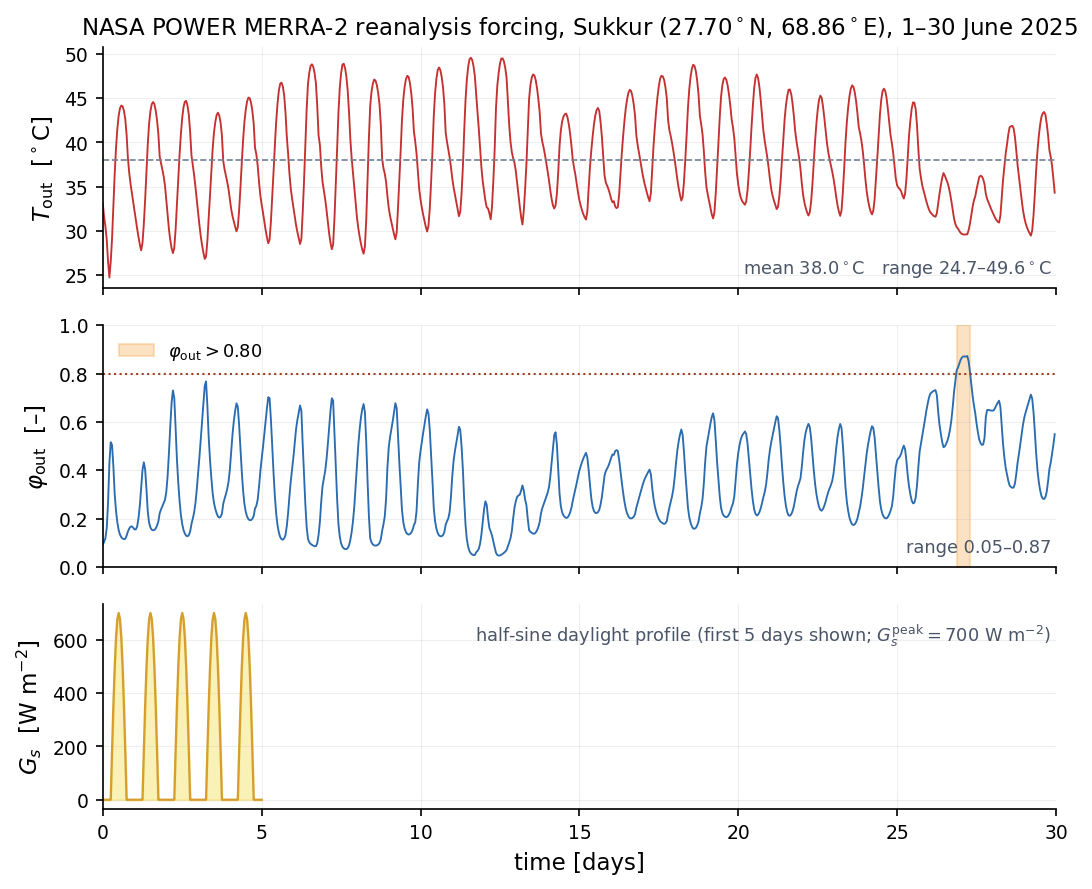

Figure 2 written


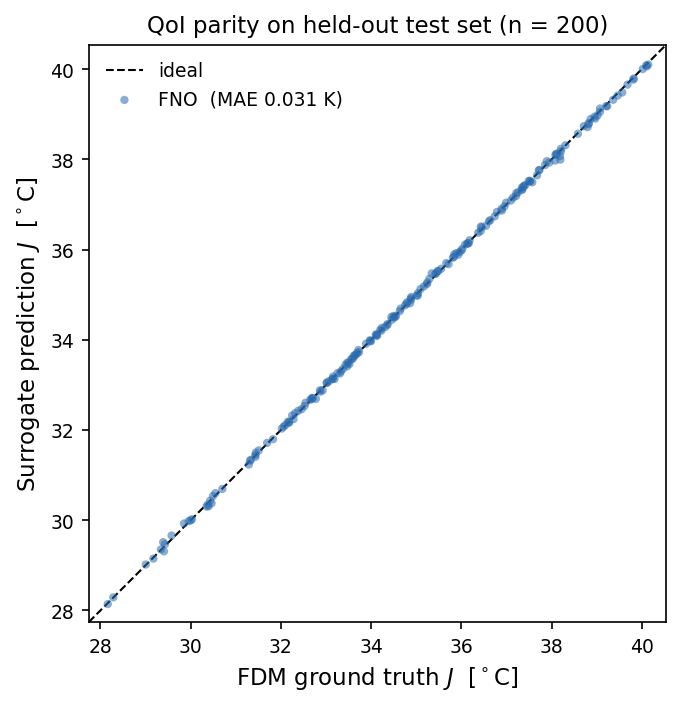

Figure 6 written


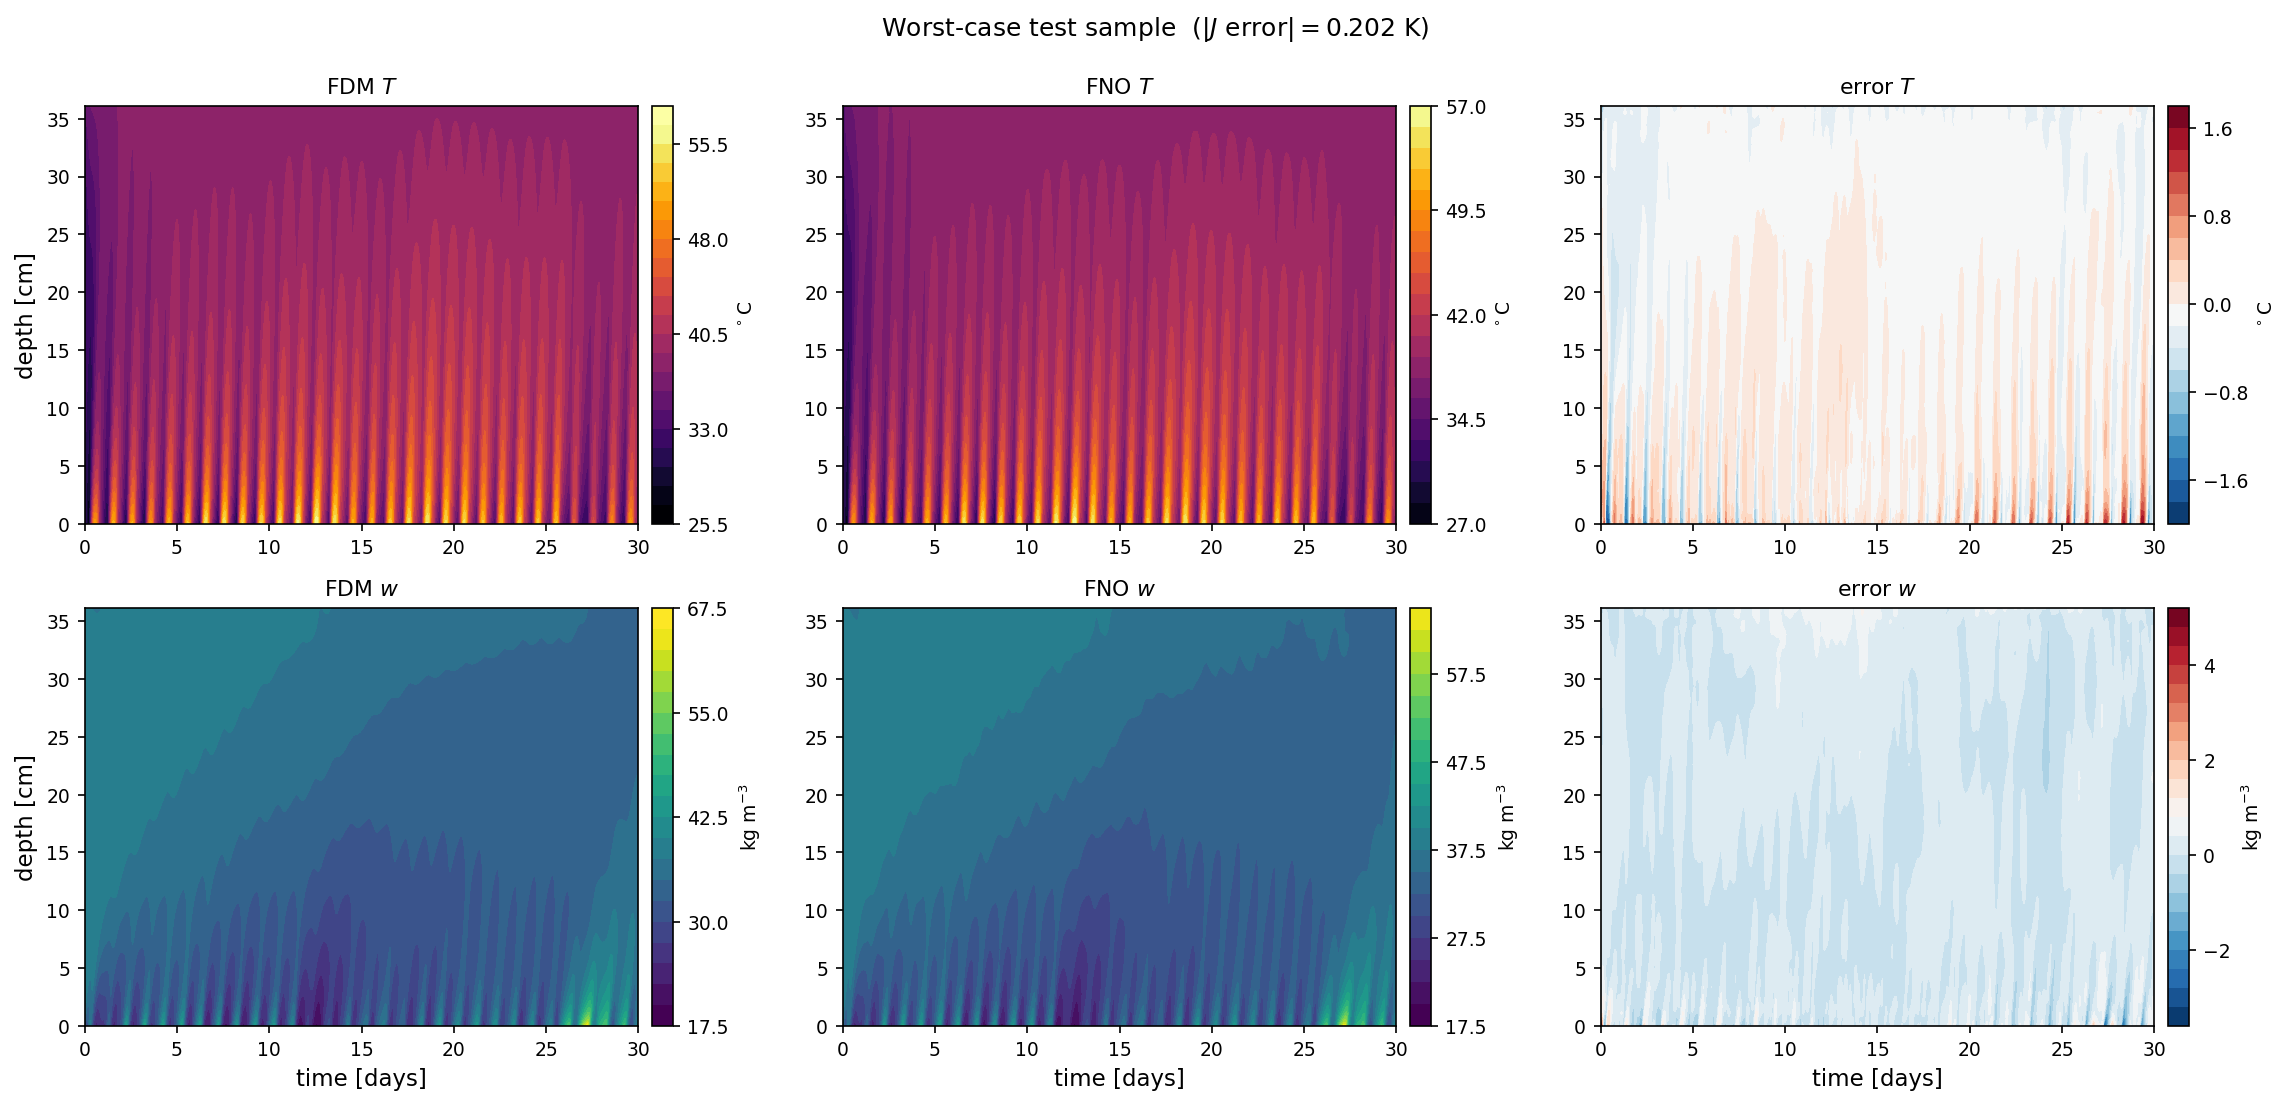

Figure 7 written


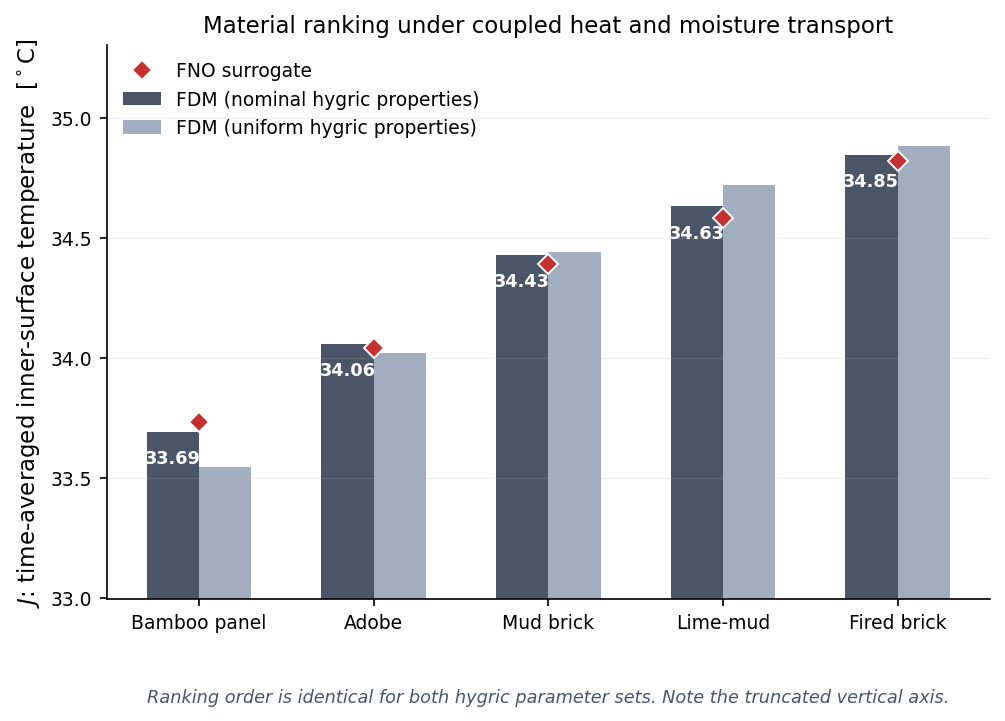

Figure 8 written


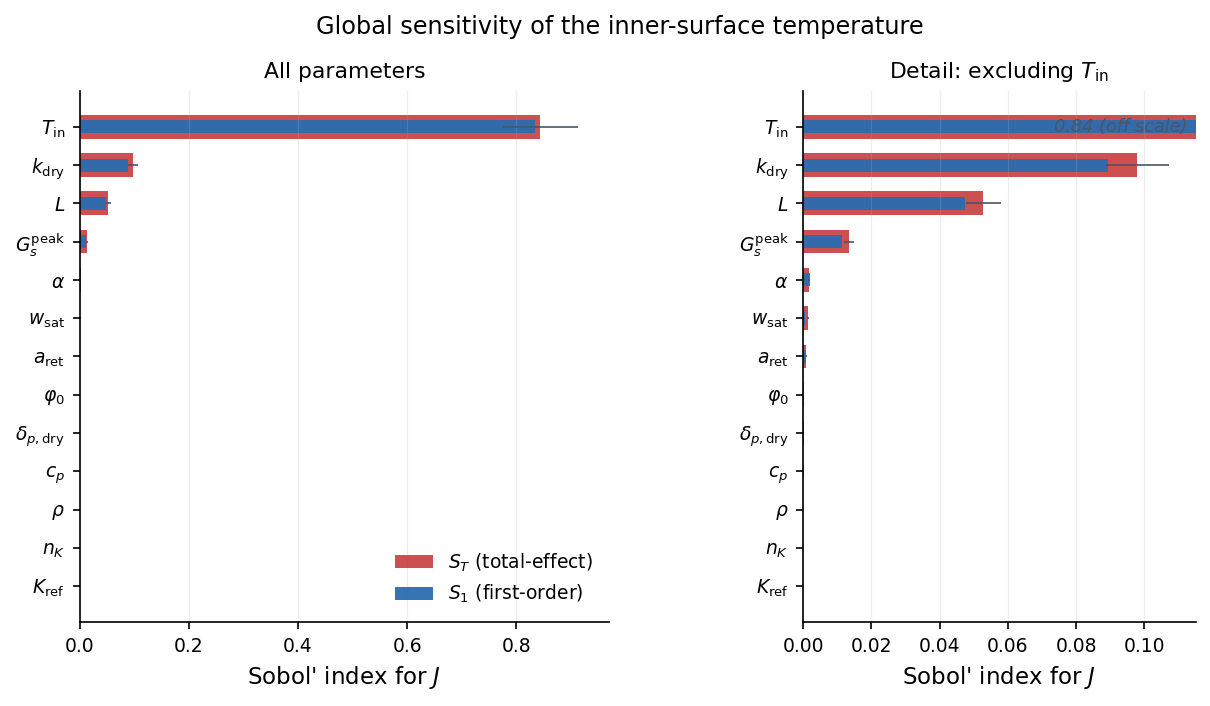

Figure 10 written


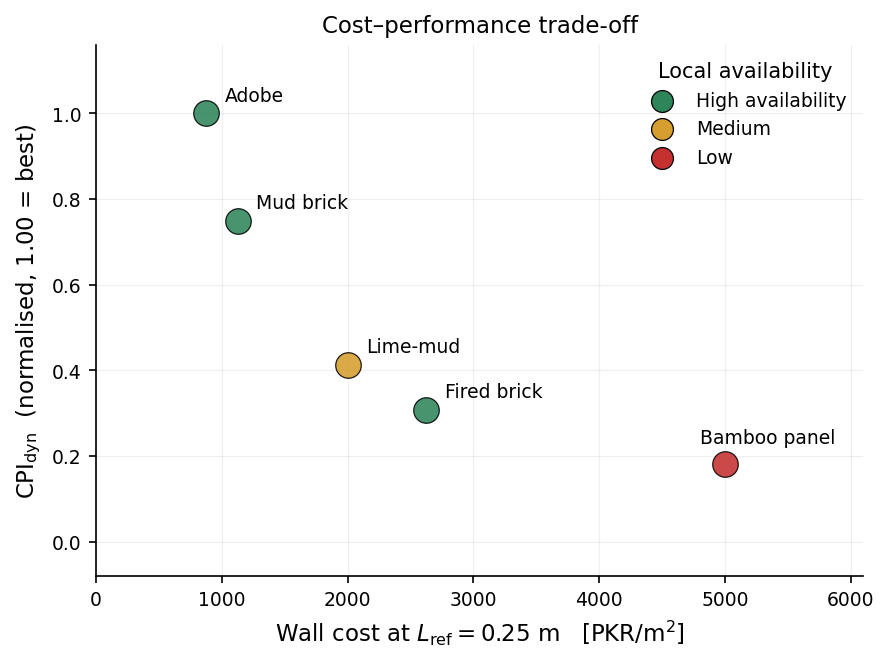

Figure 11 written

All FNO-side manuscript figures regenerated from this notebook.


In [ ]:
# ================================================================
# SECTION 12 -- Manuscript figures produced by this notebook
# ================================================================
# Every figure this notebook contributes to the manuscript is generated
# here, from data this notebook itself produced. Nothing is drawn outside
# the archived code, so a fresh run reproduces the paper's figures exactly.
#   Figure 2   climate_forcing_ham       (forcing carried in the dataset)
#   Figure 6   fno_parity_J_ham          (needs Section 8: res_fno)
#   Figure 7   fno_field_comparison_ham  (needs Sections 7-8)
#   Figure 8   material_ranking_ham      (needs Section 9: fno_J, MATERIALS)
#   Figure 10  sobol_indices_ham         (reads sobol_results_ham.csv)
#   Figure 11  cpi_tradeoff_ham          (reads cpi_results_ham.csv)
# Run order: Sections 1-4, 7, 8, 9, 12, 13, then this cell.
# ================================================================
import matplotlib.pyplot as plt
import numpy as np, csv, os

EN = '\u2013'          # en-dash; a literal "--" would render as two hyphens
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 11,
                     'legend.fontsize': 9, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
                     'figure.dpi': 150, 'savefig.bbox': 'tight'})
SHORT = {'Mud brick (unfired)': 'Mud brick', 'Clay-straw adobe': 'Adobe',
         'Lime-stabilised bamboo panel': 'Bamboo panel',
         'Fired clay brick': 'Fired brick', 'Lime-mud composite': 'Lime-mud'}
LATEX = {'k_dry': r'$k_{\mathrm{dry}}$', 'rho': r'$\rho$', 'cp': r'$c_p$',
         'alpha_moist': r'$\alpha$',
         'delta_p_dry': r'$\delta_{p,\mathrm{dry}}$',
         'K_ref': r'$K_{\mathrm{ref}}$', 'a_ret': r'$a_{\mathrm{ret}}$',
         'w_sat': r'$w_{\mathrm{sat}}$', 'L': r'$L$', 'phi_0': r'$\varphi_0$',
         'T_in_C': r'$T_{\mathrm{in}}$',
         'G_s_peak': r'$G_{s}^{\mathrm{peak}}$', 'n_K': r'$n_K$'}

# =============== FIGURE 2 -- climate forcing =====================
T_out_C = np.asarray(data['T_out_C'], float)
phi_out = np.asarray(data['phi_out'], float)
hours = np.arange(len(T_out_C)); days = hours / 24.0
G_PEAK = 700.0
G_s = G_PEAK * np.maximum(0.0, np.sin(np.pi * (np.mod(hours, 24.0) - 6.0) / 12.0))

fig, ax = plt.subplots(3, 1, figsize=(8.2, 6.6), sharex=True,
                       gridspec_kw={'height_ratios': [1, 1, 0.85], 'hspace': 0.16})
ax[0].plot(days, T_out_C, lw=0.9, color='#c53030')
ax[0].axhline(T_out_C.mean(), ls='--', lw=0.8, color='#718096')
ax[0].set_ylabel(r'$T_{\mathrm{out}}$  [$^\circ$C]')
ax[0].text(0.995, 0.06, f'mean {T_out_C.mean():.1f}$^\\circ$C   range '
           f'{T_out_C.min():.1f}{EN}{T_out_C.max():.1f}$^\\circ$C',
           transform=ax[0].transAxes, ha='right', fontsize=8.5, color='#4a5568')
ax[0].set_title(f'NASA POWER MERRA-2 reanalysis forcing, Sukkur '
                f'(27.70$^\\circ$N, 68.86$^\\circ$E), 1{EN}30 June 2025')
ax[1].plot(days, phi_out, lw=0.9, color='#2b6cb0')
ax[1].axhline(0.80, ls=':', lw=1.0, color='#9c4221')
hi = phi_out > 0.80
if hi.any():
    ax[1].fill_between(days, 0, 1, where=hi, color='#f6ad55', alpha=0.35, step='mid',
                       label=r'$\varphi_{\mathrm{out}}>0.80$')
    ax[1].legend(frameon=False, loc='upper left', fontsize=8.5)
ax[1].set_ylabel(r'$\varphi_{\mathrm{out}}$  [' + EN + ']'); ax[1].set_ylim(0, 1)
ax[1].text(0.995, 0.06, f'range {phi_out.min():.2f}{EN}{phi_out.max():.2f}',
           transform=ax[1].transAxes, ha='right', fontsize=8.5, color='#4a5568')
m = days <= 5
ax[2].plot(days[m], G_s[m], lw=1.1, color='#d69e2e')
ax[2].fill_between(days[m], 0, G_s[m], color='#f6e05e', alpha=0.45)
ax[2].set_ylabel(r'$G_s$  [W m$^{-2}$]'); ax[2].set_xlabel('time [days]')
ax[2].set_xlim(0, 30)
ax[2].text(0.995, 0.82, 'half-sine daylight profile (first 5 days shown; '
           f'$G_s^{{\\mathrm{{peak}}}}={G_PEAK:.0f}$ W m$^{{-2}}$)',
           transform=ax[2].transAxes, ha='right', fontsize=8.5, color='#4a5568')
for a in ax:
    a.grid(alpha=0.2, lw=0.5)
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)
plt.savefig(DRIVE+'climate_forcing_ham.pdf'); plt.savefig(DRIVE+'climate_forcing_ham.png')
plt.show(); print('Figure 2 written')

# =============== FIGURE 6 -- QoI parity ==========================
J_true = Jm_gt[idx_test] - 273.15
J_fno  = res_fno[4] - 273.15
fig, ax = plt.subplots(figsize=(5.2, 5.0))
lo  = min(J_true.min(), J_fno.min()) - 0.4
hi_ = max(J_true.max(), J_fno.max()) + 0.4
ax.plot([lo, hi_], [lo, hi_], 'k--', lw=1, zorder=1, label='ideal')
ax.scatter(J_true, J_fno, s=16, alpha=0.55, edgecolor='none', color='#2b6cb0',
           label=f'FNO  (MAE {res_fno[2]:.3f} K)', zorder=2)
ax.set_xlim(lo, hi_); ax.set_ylim(lo, hi_); ax.set_aspect('equal')
ax.set_xlabel(r'FDM ground truth $J$  [$^\circ$C]')
ax.set_ylabel(r'Surrogate prediction $J$  [$^\circ$C]')
ax.set_title(f'QoI parity on held-out test set (n = {len(J_true)})')
ax.legend(loc='upper left', frameon=False)
plt.savefig(DRIVE+'fno_parity_J_ham.pdf'); plt.savefig(DRIVE+'fno_parity_J_ham.png')
plt.show(); print('Figure 6 written')

# =============== FIGURE 7 -- worst-case fields ===================
Jm_test = Jm_gt[idx_test]; Jm_pred = res_fno[4]
i_worst = idx_test[int(np.argmax(np.abs(Jm_pred - Jm_test)))]

@torch.no_grad()
def _fields(i_global):
    mu_n = (mu_transform(mu_raw[i_global]) - mu_mean) / mu_std
    xg = np.broadcast_to(xi[:, None], (N_x, N_t)); tg = np.broadcast_to(tau[None, :], (N_x, N_t))
    mg = np.broadcast_to(mu_n[:, None, None], (N_PARAMS, N_x, N_t))
    xin = torch.from_numpy(np.concatenate([xg[None], tg[None], mg], 0).astype(np.float32))[None]
    p = model_fno(xin.to(device))[0].cpu().numpy()
    return p[0]*T_std + T_mean, p[1]*W_std + W_mean

T_hat, W_hat = _fields(i_worst)
D = tau * T_END / 86400.0
H = xi * mu_raw[i_worst][8] * 100
fig, ax = plt.subplots(2, 3, figsize=(15.5, 7.4))
for r, (true, hat, sym, unit, cmap) in enumerate([
        (T_field[i_worst]-273.15, T_hat-273.15, r'$T$', r'$^\circ$C', 'inferno'),
        (W_field[i_worst],        W_hat,        r'$w$', r'kg m$^{-3}$', 'viridis')]):
    vmin, vmax = min(true.min(), hat.min()), max(true.max(), hat.max())
    for c, (fld, ttl, cm, lim) in enumerate([
            (true,     f'FDM {sym}',   cmap,     (vmin, vmax)),
            (hat,      f'FNO {sym}',  cmap,     (vmin, vmax)),
            (hat-true, f'error {sym}', 'RdBu_r', None)]):
        kw = dict(levels=20, cmap=cm)
        if lim: kw.update(vmin=lim[0], vmax=lim[1])
        im = ax[r, c].contourf(D, H, fld, **kw)
        cb = fig.colorbar(im, ax=ax[r, c], pad=0.02)
        cb.ax.locator_params(nbins=5); cb.set_label(unit, fontsize=9)
        ax[r, c].set_title(ttl, fontsize=10.5)
        if r == 1: ax[r, c].set_xlabel('time [days]')
        if c == 0: ax[r, c].set_ylabel('depth [cm]')
fig.suptitle(f'Worst-case test sample  ($|J$ error$| = '
             f'{abs(Jm_pred-Jm_test).max():.3f}$ K)', y=0.99)
plt.tight_layout()
plt.savefig(DRIVE+'fno_field_comparison_ham.pdf')
plt.savefig(DRIVE+'fno_field_comparison_ham.png')
plt.show(); print('Figure 7 written')

# =============== FIGURE 8 -- material ranking ====================
rank_nom, rank_uni = {}, {}
with open(DRIVE + 'material_ranking_fdm.csv') as f:
    for row in csv.DictReader(f):
        (rank_nom if row['hygric_set'] == 'nominal' else rank_uni)[row['material']] \
            = float(row['J_mean_C'])
order = sorted(rank_nom, key=rank_nom.get)
labels = [SHORT[m] for m in order]
Jn = np.array([rank_nom[m] for m in order]); Ju = np.array([rank_uni[m] for m in order])
Jp = np.array([fno_J(np.array(MATERIALS[m] + RANK_TAIL)) - 273.15 for m in order])
x, w = np.arange(len(labels)), 0.30
fig, ax = plt.subplots(figsize=(7.6, 4.8))
ax.bar(x - w/2, Jn, w, color='#4a5568', label='FDM (nominal hygric properties)')
ax.bar(x + w/2, Ju, w, color='#a0aec0', label='FDM (uniform hygric properties)')
ax.plot(x, Jp, 'D', ms=7, color='#c53030', markeredgecolor='white',
        markeredgewidth=0.9, zorder=6, label='FNO surrogate')
top, bot = max(Jn.max(), Ju.max(), Jp.max()), min(Jn.min(), Ju.min(), Jp.min())
for xi_, j in zip(x, Jn):
    ax.text(xi_ - w/2, j - 0.055*(top-bot), f'{j:.2f}', ha='center', va='top',
            fontsize=8.5, color='white', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel(r'$J$: time-averaged inner-surface temperature  [$^\circ$C]')
ax.set_ylim(bot - 0.55, top + 0.42)
ax.set_title('Material ranking under coupled heat and moisture transport')
ax.legend(frameon=False, loc='upper left')
ax.text(0.5, -0.16, 'Ranking order is identical for both hygric parameter sets. '
        'Note the truncated vertical axis.', transform=ax.transAxes, ha='center',
        va='top', fontsize=8.5, style='italic', color='#4a5568')
ax.grid(axis='y', alpha=0.2, lw=0.6)
for s in ('top','right'): ax.spines[s].set_visible(False)
plt.savefig(DRIVE+'material_ranking_ham.pdf'); plt.savefig(DRIVE+'material_ranking_ham.png')
plt.show(); print('Figure 8 written')

# =============== FIGURE 10 -- Sobol' indices ======================
srows = list(csv.DictReader(open(DRIVE + 'sobol_results_ham.csv')))
nm  = [LATEX[r['parameter']] for r in srows]
S1  = np.array([float(r['S1']) for r in srows])
S1c = np.array([float(r['S1_conf']) for r in srows])
ST  = np.array([float(r['ST']) for r in srows])
STc = np.array([float(r['ST_conf']) for r in srows])
o   = np.argsort(-ST)
nm, S1, S1c, ST, STc = [nm[i] for i in o], S1[o], S1c[o], ST[o], STc[o]
S1p, STp = np.abs(S1), np.abs(ST)          # tiny negatives are estimator noise
y = np.arange(len(nm))[::-1]
zoom = min(0.115, max(STp[1:].max()*1.35, 0.02))
fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.6, 4.6),
                               gridspec_kw={'width_ratios': [1.35, 1], 'wspace': 0.42})
for a, xmax, ttl in ((axL, STp.max()*1.15, 'All parameters'),
                     (axR, zoom, f'Detail: excluding {nm[0]}')):
    a.barh(y, STp, xerr=STc, height=0.62, color='#c53030', alpha=0.85,
           error_kw=dict(lw=0.8, ecolor='#4a5568'), label=r'$S_T$ (total-effect)')
    a.barh(y, S1p, height=0.34, color='#2b6cb0', alpha=0.95, label=r'$S_1$ (first-order)')
    a.set_yticks(y); a.set_yticklabels(nm); a.set_xlim(0, xmax)
    a.set_xlabel(r"Sobol' index for $J$"); a.set_title(ttl, fontsize=10.5)
    a.grid(axis='x', alpha=0.22, lw=0.6)
    for s in ('top','right'): a.spines[s].set_visible(False)
axR.annotate(f'{STp[0]:.2f} (off scale)', xy=(zoom*0.98, y[0]), ha='right',
             va='center', fontsize=8.5, style='italic', color='#4a5568')
axL.legend(frameon=False, loc='lower right')
fig.suptitle('Global sensitivity of the inner-surface temperature', y=0.99, fontsize=11.5)
plt.savefig(DRIVE+'sobol_indices_ham.pdf'); plt.savefig(DRIVE+'sobol_indices_ham.png')
plt.show(); print('Figure 10 written')

# =============== FIGURE 11 -- cost-performance ====================
crows = list(csv.DictReader(open(DRIVE + 'cpi_results_ham.csv')))
COL = {'H': '#2f855a', 'M': '#d69e2e', 'L': '#c53030'}
fig, ax = plt.subplots(figsize=(6.6, 4.6))
for r in crows:
    c, cd, av, nmm = (float(r['cost_PKR_m2']), float(r['CPI_dyn_norm']),
                      r['availability'], SHORT[r['material']])
    ax.scatter(c, cd, s=150, color=COL[av], alpha=0.88, edgecolor='k',
               linewidth=0.6, zorder=3)
    dx = -12 if c > 4000 else 9
    ax.annotate(nmm, (c, cd), textcoords='offset points',
                xytext=(dx, 10 if c > 4000 else 6), fontsize=9)
ax.set_xlabel(r'Wall cost at $L_{\mathrm{ref}} = 0.25$ m   [PKR/m$^2$]')
ax.set_ylabel(r'$\mathrm{CPI}_{\mathrm{dyn}}$  (normalised, 1.00 = best)')
ax.set_title(f'Cost{EN}performance trade-off')
ax.set_xlim(0, max(float(r['cost_PKR_m2']) for r in crows)*1.22)
ax.set_ylim(-0.08, 1.16); ax.grid(alpha=0.2, lw=0.6)
for av, lab in [('H','High availability'), ('M','Medium'), ('L','Low')]:
    ax.scatter([], [], s=110, color=COL[av], edgecolor='k', linewidth=0.6, label=lab)
ax.legend(frameon=False, loc='upper right', title='Local availability')
for s in ('top','right'): ax.spines[s].set_visible(False)
plt.savefig(DRIVE+'cpi_tradeoff_ham.pdf'); plt.savefig(DRIVE+'cpi_tradeoff_ham.png')
plt.show(); print('Figure 11 written')

print('\nAll FNO-side manuscript figures regenerated from this notebook.')

[FNO@200] ep   0  train=1.9200e+00  val relL2 T+w=5.9331e-01  best=5.9331e-01
[FNO@200] ep  10  train=6.3546e-01  val relL2 T+w=1.6469e-01  best=1.6469e-01
[FNO@200] ep  20  train=5.0779e-01  val relL2 T+w=1.2613e-01  best=1.2579e-01
[FNO@200] ep  30  train=3.9093e-01  val relL2 T+w=1.1178e-01  best=1.0420e-01
[FNO@200] ep  40  train=3.1716e-01  val relL2 T+w=8.6186e-02  best=8.3167e-02
[FNO@200] ep  50  train=3.0875e-01  val relL2 T+w=7.6149e-02  best=7.6149e-02
[FNO@200] ep  60  train=2.4982e-01  val relL2 T+w=6.7761e-02  best=6.6411e-02
[FNO@200] ep  70  train=2.3240e-01  val relL2 T+w=6.6552e-02  best=6.1295e-02
[FNO@200] ep  80  train=2.2027e-01  val relL2 T+w=6.2320e-02  best=5.8787e-02
[FNO@200] ep  90  train=1.9661e-01  val relL2 T+w=5.7367e-02  best=5.6682e-02
[FNO@200] ep 100  train=1.9443e-01  val relL2 T+w=5.4091e-02  best=5.4091e-02
[FNO@200] ep 110  train=1.5653e-01  val relL2 T+w=5.3553e-02  best=5.2405e-02
[FNO@200] ep 120  train=1.7071e-01  val relL2 T+w=5.5601e-02  be

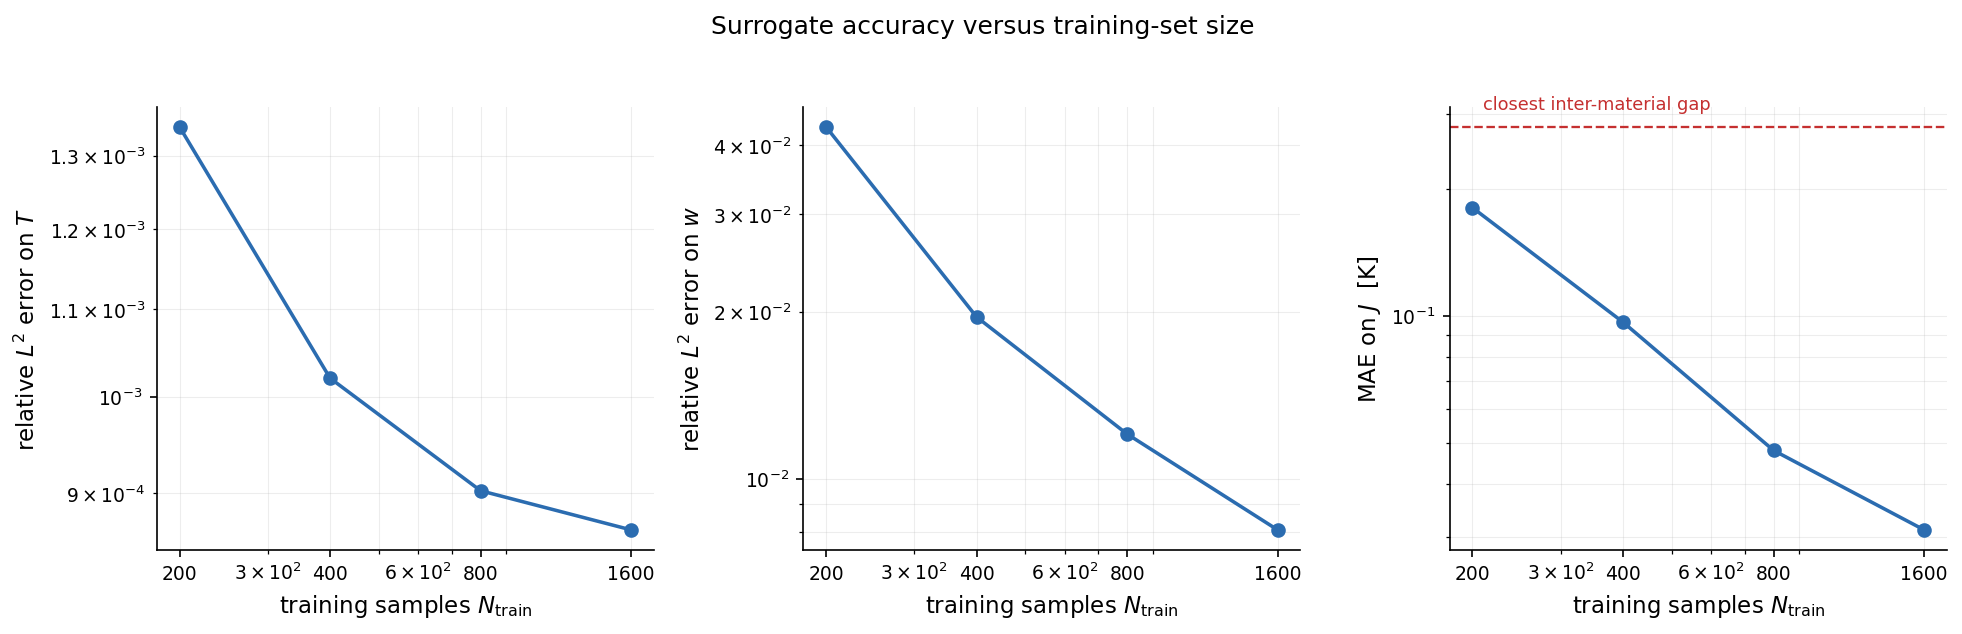


Saved: data_efficiency_ham.csv, data_efficiency_ham.pdf/.png


In [ ]:
"""
================================================================
SECTION 13 -- Data-efficiency study            [manuscript Sec 7.x]
================================================================
How does surrogate accuracy depend on the number of FDM training
solutions? This justifies the chosen dataset size: the requirement is
not merely the 5% field-error criterion but the resolution needed to
separate materials whose J values differ by as little as 0.28 K.

Nested subsets of the existing training split (200 subset of 400 subset
of 800 subset of 1600), identical validation and test sets, identical
seed, architecture and epoch budget. No new FDM runs required.
N = 1600 reuses the Section 5 checkpoint.

Resumable: each completed size is appended to data_efficiency_ham.csv.
Cost: about 2.3 h for the three new sizes on a T4.
================================================================
"""
import csv, time

SIZES  = [200, 400, 800, 1600]
DE_CSV = DRIVE + 'data_efficiency_ham.csv'

done = {}
if os.path.exists(DE_CSV):
    for r in csv.DictReader(open(DE_CSV)):
        done[int(r['N_train'])] = r
    print(f"resume: {len(done)}/{len(SIZES)} sizes recorded")

for n_train in SIZES:
    if n_train in done:
        print(f"  skip  N={n_train:5d}  (already recorded)"); continue
    if n_train == 1600:
        m, mins = model_fno, float('nan')          # reuse Section 5 result
    else:
        sub = idx_train[:n_train]                  # nested subset
        tr_ld = DataLoader(SindhHamDataset(mu_raw[sub], T_tr[sub], W_tr[sub],
                                           xi, tau_tr, **norm_stats),
                           batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
        torch.manual_seed(42); np.random.seed(42)
        m = FNO2dHam(**MODEL_CONFIG).to(device)
        t0 = time.time()
        m, _ = train_model(m, tr_ld, val_loader, n_epochs=N_EPOCHS_FULL,
                           tag=f"FNO@{n_train}")
        mins = (time.time() - t0) / 60
    eT, ew, maeJ, _, _ = evaluate_model(m, mu_raw[idx_test], T_field[idx_test],
                                        W_field[idx_test], Jm_gt[idx_test],
                                        Jp_gt[idx_test])
    new = not os.path.exists(DE_CSV)
    with open(DE_CSV, 'a', newline='') as f:
        wr = csv.DictWriter(f, fieldnames=['N_train','relL2_T','relL2_w','MAE_J','minutes'])
        if new: wr.writeheader()
        wr.writerow(dict(N_train=n_train, relL2_T=eT, relL2_w=ew,
                         MAE_J=maeJ, minutes=mins))
    print(f"  DONE  N={n_train:5d}   relL2 T={eT:.3e}  w={ew:.3e}  MAE J={maeJ:.4f} K")
    if n_train != 1600:
        del m
        if device.type == 'cuda': torch.cuda.empty_cache()

# ---------------- report ----------------
rows = {int(r['N_train']): r for r in csv.DictReader(open(DE_CSV))}
Ns   = np.array(SIZES, float)
get  = lambda c: np.array([float(rows[n][c]) for n in SIZES])

SMALLEST_GAP = 0.28      # K, closest pair in tab:ranking (mud brick / lime-mud)
print("\n" + "=" * 74)
print("DATA EFFICIENCY: accuracy vs number of FDM training solutions")
print("=" * 74)
print(f"{'N_train':>9}{'relL2 T':>12}{'relL2 w':>12}{'MAE J (K)':>12}"
      f"{'MAE J / smallest gap':>22}")
for n in SIZES:
    r = rows[n]
    print(f"{n:>9}{float(r['relL2_T']):>12.2e}{float(r['relL2_w']):>12.2e}"
          f"{float(r['MAE_J']):>12.4f}{100*float(r['MAE_J'])/SMALLEST_GAP:>21.0f}%")
print("\nThe last column is the design criterion: the surrogate must resolve")
print("differences far smaller than the closest inter-material gap (0.28 K).")

print("\nLaTeX rows for tab:data_efficiency:")
for n in SIZES:
    r = rows[n]
    print(f"{n} & {float(r['relL2_T']):.2e} & {float(r['relL2_w']):.2e} & "
          f"{float(r['MAE_J']):.3f} & {100*float(r['MAE_J'])/SMALLEST_GAP:.0f}\\% \\\\")

# ---------------- figure ----------------
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 11,
                     'legend.fontsize': 9, 'figure.dpi': 150, 'savefig.bbox': 'tight'})
fig, ax = plt.subplots(1, 3, figsize=(13.2, 4.1))
for a, (c, ylab) in zip(ax, [('relL2_T', r'relative $L^2$ error on $T$'),
                             ('relL2_w', r'relative $L^2$ error on $w$'),
                             ('MAE_J',   r'MAE on $J$  [K]')]):
    a.loglog(Ns, get(c), 'o-', color='#2b6cb0', ms=6, lw=1.7)
    a.set_xticks(SIZES); a.set_xticklabels([str(s) for s in SIZES])
    a.set_xlabel(r'training samples $N_{\mathrm{train}}$'); a.set_ylabel(ylab)
    a.grid(True, which='both', alpha=0.22, lw=0.5)
    for s in ('top', 'right'): a.spines[s].set_visible(False)
ax[2].axhline(SMALLEST_GAP, ls='--', lw=1.1, color='#c53030')
ax[2].text(Ns[0]*1.05, SMALLEST_GAP*1.1, 'closest inter-material gap',
           fontsize=8.5, color='#c53030')
fig.suptitle('Surrogate accuracy versus training-set size', y=1.02)
plt.tight_layout()
plt.savefig(DRIVE + 'data_efficiency_ham.pdf')
plt.savefig(DRIVE + 'data_efficiency_ham.png')
plt.show()
print("\nSaved: data_efficiency_ham.csv, data_efficiency_ham.pdf/.png")


In [12]:
# ================================================================
# SECTION 14 -- Scalar-QoI regression baselines vs the neural operator
# ================================================================
# Question a reviewer will ask: the decision quantity J is a SCALAR, so why
# learn a full space-time operator rather than regress J directly on the
# 13 parameters?  This cell answers it with three direct regressors trained
# on EXACTLY the same split, inputs and normalisation as the FNO:
#
#   (1) quadratic ridge regression  -- a floor
#   (2) multilayer perceptron        -- the usual neural baseline
#   (3) Gaussian process, ARD Matern -- the standard strong surrogate for
#                                       smooth, low-dimensional scalar maps
#
# and compares them with the FNO at four levels:
#   A. test-set accuracy on J and J_peak
#   B. data efficiency (nested 200/400/800/1600, same subsets as Section 13)
#   C. DECISION-level fidelity: J on the correlated-property Monte Carlo
#      sets of the FDM notebook, and the pairwise ordering probabilities
#      computed with the same paired estimator as the FDM notebook
#   D. Sobol' indices (same Saltelli design size as Section 10)
#
# Requires: Section 1.  Optional: Sections 3+6 (model_fno) and 7 (res_fno)
# for the FNO rows.  Reads: data_efficiency_ham.csv, sobol_results_ham.csv,
# ham_uncertainty_mc.npz, material_ranking_fdm.csv.
# Writes: baseline_*_ham.csv.   Runtime: roughly 10-20 min on Colab CPU.
# ================================================================
import time, csv, os, warnings
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

FDM_S_PER_RUN = 2.08                 # s per 30-day coupled FDM solve
GAP_K = 0.203                        # closest inter-material gap (Sec 7.5)
HAVE_FNO = 'model_fno' in globals()

# ---------------- inputs: identical transform to the FNO ----------------
def feats(mu_rows):
    return ((mu_transform(np.asarray(mu_rows, np.float32)) - mu_mean)
            / mu_std).astype(np.float64)

X_all = feats(mu_raw)
yJ, yP = Jm_gt.astype(np.float64), Jp_gt.astype(np.float64)       # K
Xtr, Xte = X_all[idx_train], X_all[idx_test]

def make_quad():
    return make_pipeline(PolynomialFeatures(2, include_bias=False),
                         StandardScaler(),
                         RidgeCV(alphas=np.logspace(-8, 2, 41)))

class ScaledMLP:
    """MLP on standardised targets (sklearn MLPs are scale-sensitive)."""
    def __init__(self, seed=0):
        self.m = MLPRegressor(hidden_layer_sizes=(256, 256, 256),
                              activation='tanh', solver='adam',
                              learning_rate_init=1e-3, alpha=1e-6,
                              batch_size=64, max_iter=4000,
                              early_stopping=True, validation_fraction=0.1,
                              n_iter_no_change=150, tol=1e-8,
                              random_state=seed)
    def fit(self, X, y):
        self.mu, self.sd = y.mean(), y.std()
        self.m.fit(X, (y - self.mu) / self.sd); return self
    def predict(self, X):
        return self.m.predict(X) * self.sd + self.mu

def make_gp(restarts=2):
    k = (ConstantKernel(1.0, (1e-3, 1e3))
         * Matern(length_scale=np.ones(N_PARAMS),
                  length_scale_bounds=(1e-2, 1e3), nu=2.5)
         + WhiteKernel(1e-6, (1e-10, 1e-1)))
    return GaussianProcessRegressor(kernel=k, normalize_y=True,
                                    n_restarts_optimizer=restarts,
                                    random_state=0)

MODELS = {'Quadratic ridge': make_quad, 'MLP (3x256)': ScaledMLP,
          'Gaussian process': make_gp}

def scores(y, p):
    e = p - y
    return dict(MAE=float(np.mean(np.abs(e))), MAX=float(np.max(np.abs(e))),
                RMSE=float(np.sqrt(np.mean(e**2))),
                R2=float(1 - np.sum(e**2) / np.sum((y - y.mean())**2)))

# ================================================================
# A. test-set accuracy
# ================================================================
print('=' * 78); print('A. TEST-SET ACCURACY  (N_train = %d, N_test = %d)'
                        % (len(idx_train), len(idx_test))); print('=' * 78)
fitted, acc_rows = {}, []
for name, ctor in MODELS.items():
    t0 = time.time()
    mJ = ctor().fit(Xtr, yJ[idx_train])
    mP = ctor().fit(Xtr, yP[idx_train])
    fit_s = time.time() - t0
    fitted[name] = (mJ, mP)
    sJ = scores(yJ[idx_test], mJ.predict(Xte))
    sP = scores(yP[idx_test], mP.predict(Xte))
    mJ.predict(Xte[:1])                                     # warm-up
    t0 = time.time()
    for _ in range(50): mJ.predict(Xte[:1])
    ms1 = (time.time() - t0) / 50 * 1e3
    t0 = time.time(); mJ.predict(Xte); msb = (time.time() - t0) / len(Xte) * 1e3
    acc_rows.append(dict(model=name, MAE_J=sJ['MAE'], MAX_J=sJ['MAX'],
                         R2_J=sJ['R2'], MAE_Jpk=sP['MAE'], MAX_Jpk=sP['MAX'],
                         R2_Jpk=sP['R2'], fit_s=fit_s, ms_single=ms1,
                         ms_batch=msb, fields='no'))
    if name == 'Gaussian process':
        print('  GP kernel (J):', mJ.kernel_)

if HAVE_FNO and 'res_fno' in globals():
    acc_rows.append(dict(model='FNO (operator)', MAE_J=float(res_fno[2]),
                         MAX_J=float('nan'), R2_J=float('nan'),
                         MAE_Jpk=float(res_fno[3]), MAX_Jpk=float('nan'),
                         R2_Jpk=float('nan'), fit_s=float('nan'),
                         ms_single=float('nan'), ms_batch=float('nan'),
                         fields='T(x,t), w(x,t)'))

hdr = (f"{'model':<18}{'MAE J':>9}{'max J':>9}{'R2 J':>9}{'MAE Jpk':>10}"
       f"{'max Jpk':>9}{'fit s':>8}{'ms/1':>8}  MAE/gap")
print(hdr); print('-' * len(hdr))
for r in acc_rows:
    f = lambda v, w, d: (f'{v:>{w}.{d}f}' if np.isfinite(v) else f'{"-":>{w}}')
    print(f"{r['model']:<18}{f(r['MAE_J'],9,4)}{f(r['MAX_J'],9,4)}"
          f"{f(r['R2_J'],9,5)}{f(r['MAE_Jpk'],10,4)}{f(r['MAX_Jpk'],9,4)}"
          f"{f(r['fit_s'],8,1)}{f(r['ms_single'],8,3)}"
          f"  {100*r['MAE_J']/GAP_K:5.1f}%")
with open(DRIVE + 'baseline_accuracy_ham.csv', 'w', newline='') as fh:
    w_ = csv.DictWriter(fh, fieldnames=list(acc_rows[0])); w_.writeheader()
    w_.writerows(acc_rows)

# ================================================================
# B. data efficiency -- same nested subsets as Section 13
# ================================================================
print('\n' + '=' * 78); print('B. DATA EFFICIENCY (nested subsets of idx_train)'); print('=' * 78)
fno_de = {}
try:
    for r in csv.DictReader(open(DRIVE + 'data_efficiency_ham.csv')):
        fno_de[int(r['N_train'])] = float(r['MAE_J'])
except Exception:
    print('  (data_efficiency_ham.csv not found -- FNO column left blank)')
de_rows = []
print(f"{'N_train':>8}{'quad MAE':>11}{'GP MAE':>10}{'FNO MAE':>10}"
      f"{'GP/gap':>9}{'FNO/gap':>9}")
for n in [200, 400, 800, 1600]:
    sub = idx_train[:n]
    q = make_quad().fit(X_all[sub], yJ[sub])
    g = fitted['Gaussian process'][0] if n == len(idx_train) else \
        make_gp(restarts=1).fit(X_all[sub], yJ[sub])
    mq = scores(yJ[idx_test], q.predict(Xte))['MAE']
    mg = scores(yJ[idx_test], g.predict(Xte))['MAE']
    mf = fno_de.get(n, float('nan'))
    de_rows.append(dict(N_train=n, MAE_quad=mq, MAE_GP=mg, MAE_FNO=mf))
    print(f"{n:>8}{mq:>11.4f}{mg:>10.4f}"
          f"{(f'{mf:>10.4f}' if np.isfinite(mf) else f'{chr(45):>10}')}"
          f"{100*mg/GAP_K:>8.1f}%"
          f"{(f'{100*mf/GAP_K:>8.1f}%' if np.isfinite(mf) else f'{chr(45):>9}')}")
with open(DRIVE + 'baseline_data_efficiency_ham.csv', 'w', newline='') as fh:
    w_ = csv.DictWriter(fh, fieldnames=list(de_rows[0])); w_.writeheader()
    w_.writerows(de_rows)

# ================================================================
# C. DECISION-level fidelity on the correlated-property Monte Carlo
# ================================================================
print('\n' + '=' * 78); print('C. DECISION-LEVEL FIDELITY (Sec 7.6 Monte Carlo sets)'); print('=' * 78)

@torch.no_grad()
def fno_J_rows(mu_rows, batch=32):
    """J [deg C] for raw (M,13) parameter rows via the trained FNO."""
    model_fno.eval()
    xg = np.broadcast_to(xi[:, None], (N_x, N_t))
    tg = np.broadcast_to(tau[None, :], (N_x, N_t))
    t_h = torch.from_numpy(np.asarray(tau) * T_END).to(device)
    out = np.zeros(len(mu_rows))
    for s in range(0, len(mu_rows), batch):
        ch = mu_rows[s:s + batch]
        mu_n = (mu_transform(ch.astype(np.float32)) - mu_mean) / mu_std
        xin = np.empty((len(ch), N_PARAMS + 2, N_x, N_t), np.float32)
        xin[:, 0] = xg; xin[:, 1] = tg; xin[:, 2:] = mu_n[:, :, None, None]
        Tp = model_fno(torch.from_numpy(xin).to(device))[:, 0] * T_std + T_mean
        out[s:s + len(ch)] = (torch.trapezoid(Tp[:, -1, :], t_h, dim=1)
                              / T_END).cpu().numpy() - 273.15
    return out

uq_rows = []
try:
    uq = np.load(DRIVE + 'ham_uncertainty_mc.npz', allow_pickle=True)
    names = [str(s) for s in uq['names']]
    n_fdm = int(uq['n_fdm'])
    gpJ = fitted['Gaussian process'][0]
    surr = {'GP': lambda M: gpJ.predict(feats(M)) - 273.15}
    if HAVE_FNO:
        surr['FNO'] = fno_J_rows
    J_fdm = {nm: uq[f'J_{i}'] for i, nm in enumerate(names)}
    J_s = {k: {} for k in surr}
    for k, fn in surr.items():
        for i, nm in enumerate(names):
            J_s[k][nm] = fn(uq[f'mu_{i}'])
    print(f"{'material':30s}" + ''.join(f'{k+" MAE":>11}{k+" max":>10}' for k in surr))
    for nm in names:
        line = f'{nm:30s}'
        for k in surr:
            e = np.abs(J_s[k][nm][:n_fdm] - J_fdm[nm])
            line += f'{e.mean():>11.4f}{e.max():>10.4f}'
        print(line)
    base = sorted(names, key=lambda nm: J_fdm[nm].mean())
    print(f"\n  pairwise P(J_a < J_b), same paired estimator as the FDM notebook")
    hdr = f"{'pair':44s}{'FDM(64)':>9}" + ''.join(
        f'{k+"(64)":>9}{k+"(all)":>10}' for k in surr)
    print(hdr); print('-' * len(hdr))
    agree = {k: 0 for k in surr}; n_pairs = 0
    for a in range(len(base)):
        for b in range(a + 1, len(base)):
            A, B = base[a], base[b]
            pf = float(np.mean(J_fdm[A] < J_fdm[B]))
            row = dict(pair=f'{A} < {B}', P_FDM64=pf)
            line = f'{A[:20]:20s} < {B[:21]:21s}{pf:>9.2f}'
            for k in surr:
                p64 = float(np.mean(J_s[k][A][:n_fdm] < J_s[k][B][:n_fdm]))
                pall = float(np.mean(J_s[k][A] < J_s[k][B]))
                row[f'P_{k}64'] = p64; row[f'P_{k}all'] = pall
                line += f'{p64:>9.2f}{pall:>10.2f}'
                agree[k] += int((pf > 0.95) == (p64 > 0.95))
            n_pairs += 1; uq_rows.append(row); print(line)
    for k in surr:
        print(f'  {k}: resolved/unresolved verdict (P>0.95) matches FDM on '
              f'{agree[k]}/{n_pairs} pairs')
    with open(DRIVE + 'baseline_uq_ham.csv', 'w', newline='') as fh:
        w_ = csv.DictWriter(fh, fieldnames=list(uq_rows[0])); w_.writeheader()
        w_.writerows(uq_rows)
except Exception as ex:
    print(f'  skipped: {ex}')

# ---- nominal five-material ranking, with GP predictive uncertainty ----
try:
    MATS = MATERIALS
except NameError:
    MATS = {
        'Mud brick (unfired)':          [0.45, 1600, 880,  0.005, 2.41e-11, 2.5e-13, 2.5, 150],
        'Clay-straw adobe':             [0.35, 1400, 1000, 0.004, 3.22e-11, 2.0e-13, 2.5, 180],
        'Lime-stabilised bamboo panel': [0.25, 900,  1800, 0.003, 4.83e-11, 1.0e-13, 1.5, 200],
        'Fired clay brick':             [0.590, 1831, 825, 0.005, 8.73e-12, 4.0e-13, 5.0, 200],
        'Lime-mud composite':           [0.55, 1500, 900,  0.004, 1.93e-11, 2.0e-13, 3.0, 100]}
TAIL = [0.25, 0.30, 32.0, 700.0, 6.0]
fdm_nom = {}
try:
    for r in csv.DictReader(open(DRIVE + 'material_ranking_fdm.csv')):
        if r['hygric_set'] == 'nominal':
            fdm_nom[r['material']] = float(r['J_mean_C'])
except Exception:
    pass
M_nom = np.array([MATS[m] + TAIL for m in MATS])
gm, gs = fitted['Gaussian process'][0].predict(feats(M_nom), return_std=True)
print(f"\n  nominal ranking   {'FDM':>8}{'GP mean':>9}{'GP 2sd':>8}{'|err|':>8}")
for m, mu_, sd in zip(MATS, gm - 273.15, gs):
    fv = fdm_nom.get(m, float('nan'))
    print(f'  {m:30s}{fv:>8.3f}{mu_:>9.3f}{2*sd:>8.3f}{abs(mu_-fv):>8.3f}')

# ================================================================
# D. Sobol' indices through the GP (same design size as Section 10)
# ================================================================
print('\n' + '=' * 78); print("D. SOBOL' INDICES: GP vs FNO"); print('=' * 78)
try:
    from SALib.sample import sobol as _ss
    from SALib.analyze import sobol as _sa
except Exception:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'SALib>=1.4'])
    from SALib.sample import sobol as _ss
    from SALib.analyze import sobol as _sa
LO = np.array([0.20, 800, 650, 0.001, 1e-12, 5e-14, 1.0, 50, 0.15, 0.10, 25, 400, 4.0])
HI = np.array([1.50, 2200, 2000, 0.010, 3e-10, 1e-12, 6.0, 300, 0.45, 0.60, 38, 900, 8.0])
prob = {'num_vars': N_PARAMS, 'names': list(PARAM_NAMES),
        'bounds': [[float(a), float(b)] for a, b in zip(LO, HI)]}
try:
    PV = _ss.sample(prob, 1024, calc_second_order=False, seed=0)
except TypeError:
    PV = _ss.sample(prob, 1024, calc_second_order=False)
t0 = time.time()
Jg = fitted['Gaussian process'][0].predict(feats(PV)) - 273.15
t_gp = time.time() - t0
Sg = _sa.analyze(prob, Jg, calc_second_order=False, print_to_console=False)
fno_st = {}
try:
    for r in csv.DictReader(open(DRIVE + 'sobol_results_ham.csv')):
        fno_st[r['parameter']] = (float(r['ST']), float(r['ST_conf']))
except Exception:
    print('  (sobol_results_ham.csv not found -- FNO column left blank)')
print(f'  {len(PV)} GP evaluations in {t_gp:.2f} s')
print(f"{'parameter':<14}{'GP ST':>9}{'+/-':>8}{'FNO ST':>9}{'+/-':>8}{'|diff|':>9}")
sob_rows = []
for i in np.argsort(-Sg['ST']):
    nm = PARAM_NAMES[i]
    f_, fc = fno_st.get(nm, (float('nan'), float('nan')))
    sob_rows.append(dict(parameter=nm, ST_GP=float(Sg['ST'][i]),
                         ST_GP_conf=float(Sg['ST_conf'][i]), ST_FNO=f_,
                         ST_FNO_conf=fc))
    print(f"{nm:<14}{Sg['ST'][i]:>9.3f}{Sg['ST_conf'][i]:>8.3f}"
          f"{f_:>9.3f}{fc:>8.3f}{abs(Sg['ST'][i]-f_):>9.3f}")
with open(DRIVE + 'baseline_sobol_ham.csv', 'w', newline='') as fh:
    w_ = csv.DictWriter(fh, fieldnames=list(sob_rows[0])); w_.writeheader()
    w_.writerows(sob_rows)

# ================================================================
print('\n' + '=' * 78); print('SUMMARY FOR THE MANUSCRIPT'); print('=' * 78)
best = min((r for r in acc_rows if r['model'] != 'FNO (operator)'),
           key=lambda r: r['MAE_J'])
print(f"  best direct regressor on J : {best['model']}  "
      f"MAE {best['MAE_J']:.4f} K ({100*best['MAE_J']/GAP_K:.1f}% of the gap)")
if 'res_fno' in globals():
    print(f"  FNO on J                   : MAE {float(res_fno[2]):.4f} K "
          f"({100*float(res_fno[2])/GAP_K:.1f}% of the gap)")
    print(f"  J_peak   best direct {best['MAE_Jpk']:.4f} K  |  "
          f"FNO {float(res_fno[3]):.4f} K")
print('  saved: baseline_accuracy_ham.csv, baseline_data_efficiency_ham.csv,')
print('         baseline_uq_ham.csv, baseline_sobol_ham.csv')

A. TEST-SET ACCURACY  (N_train = 1600, N_test = 200)
  GP kernel (J): 17.8**2 * Matern(length_scale=[31.9, 498, 466, 80.7, 83.1, 1e+03, 41.9, 64.3, 36, 86, 57.5, 147, 1e+03], nu=2.5) + WhiteKernel(noise_level=1e-10)
model                 MAE J    max J     R2 J   MAE Jpk  max Jpk   fit s    ms/1  MAE/gap
-----------------------------------------------------------------------------------------
Quadratic ridge      0.0563   0.3671  0.99922    0.2771   1.4324     0.7   1.999   27.7%
MLP (3x256)          0.0282   0.1477  0.99982    0.0736   0.4824   196.8   0.258   13.9%
Gaussian process     0.0061   0.0515  0.99999    0.0686   0.5292   718.5   0.990    3.0%
FNO (operator)       0.0311        -        -    0.1235        -       -       -   15.3%

B. DATA EFFICIENCY (nested subsets of idx_train)
 N_train   quad MAE    GP MAE   FNO MAE   GP/gap  FNO/gap
     200     0.1086    0.0291    0.1802    14.3%    88.8%
     400     0.0766    0.0179    0.0965     8.8%    47.6%
     800     0.0609    0

## Where each result goes in the manuscript

| Manuscript location | Produced by |
|---|---|
| tab:fno_acc | Section 7 (LaTeX row printed) |
| resolution-transfer statement, Sec 6.3 | Section 7 (penalty line) |
| tab:ranking, surrogate column | Section 8 |
| speed-up, contribution (iii) and Sec 9.4 | Section 9 |
| tab:sobol and fig:sobol | Section 10 |
| tab:cpi_results and fig:cpi | Section 11 |
| Figures 2, 5, 6, 7, 8, 9 | Section 12 |
| tab:data_efficiency and the dataset-size justification (Sec 6.2) | Section 13 |

Every figure and table in the manuscript is regenerated by this notebook from
the stored dataset, so a fresh run reproduces the published results exactly.